<a href="https://colab.research.google.com/github/nemoiitkgp/FWI-Codes-PhD/blob/main/Codes_for_PP_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install devito

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.3/29.3 MB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.1/45.1 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.9/132.9 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.8/98.8 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 9.4 MB/s eta 0:00:00
  Created wheel for cgen: filename=cgen-2025.1-py3-none-any.whl size=19882 sha256=3c333a155f97ca1d58b290aef8a852e387c2cd6147d6488e1d28f495c867c2fe
  Stored in directory: /root/.cache/pip/wheels/50/1a/02/97f23c102994cf34e52e405bc2e2889aaf463fdcb37d23ca3a
  Created wheel for codepy: filename=codepy-2023.1-py3-none-any.whl size=24869 sha256=360b42b2ee5

# Single Anomaly (Low Velocity)

### Steepest Descent

--- Starting Improved Multiscale FWI ---

>> Stage 1: frequency 3.0 Hz
   Iteration 1/80 | Objective: 7.6375e+06
   Iteration 11/80 | Objective: 1.8043e+06
   Iteration 21/80 | Objective: 2.2012e+06
   Iteration 31/80 | Objective: 3.3063e+06
   Iteration 41/80 | Objective: 1.3779e+06
   Iteration 51/80 | Objective: 1.2970e+06
   Iteration 61/80 | Objective: 1.2756e+06
   Iteration 71/80 | Objective: 1.2590e+06

>> Stage 2: frequency 8.0 Hz
   Iteration 1/60 | Objective: 2.8606e+05
   Iteration 11/60 | Objective: 1.8712e+04
   Iteration 21/60 | Objective: 2.3849e+04
   Iteration 31/60 | Objective: 2.2315e+04
   Iteration 41/60 | Objective: 2.0315e+04
   Iteration 51/60 | Objective: 1.9107e+04

>> Stage 3: frequency 15.0 Hz
   Iteration 1/40 | Objective: 2.9895e+04
   Iteration 11/40 | Objective: 1.5512e+05
   Iteration 21/40 | Objective: 1.5519e+05
   Iteration 31/40 | Objective: 1.5572e+05

>> Stage 4: frequency 25.0 Hz
   Iteration 1/20 | Objective: 8.4292e+04
   Iteration 11/20 | Obj

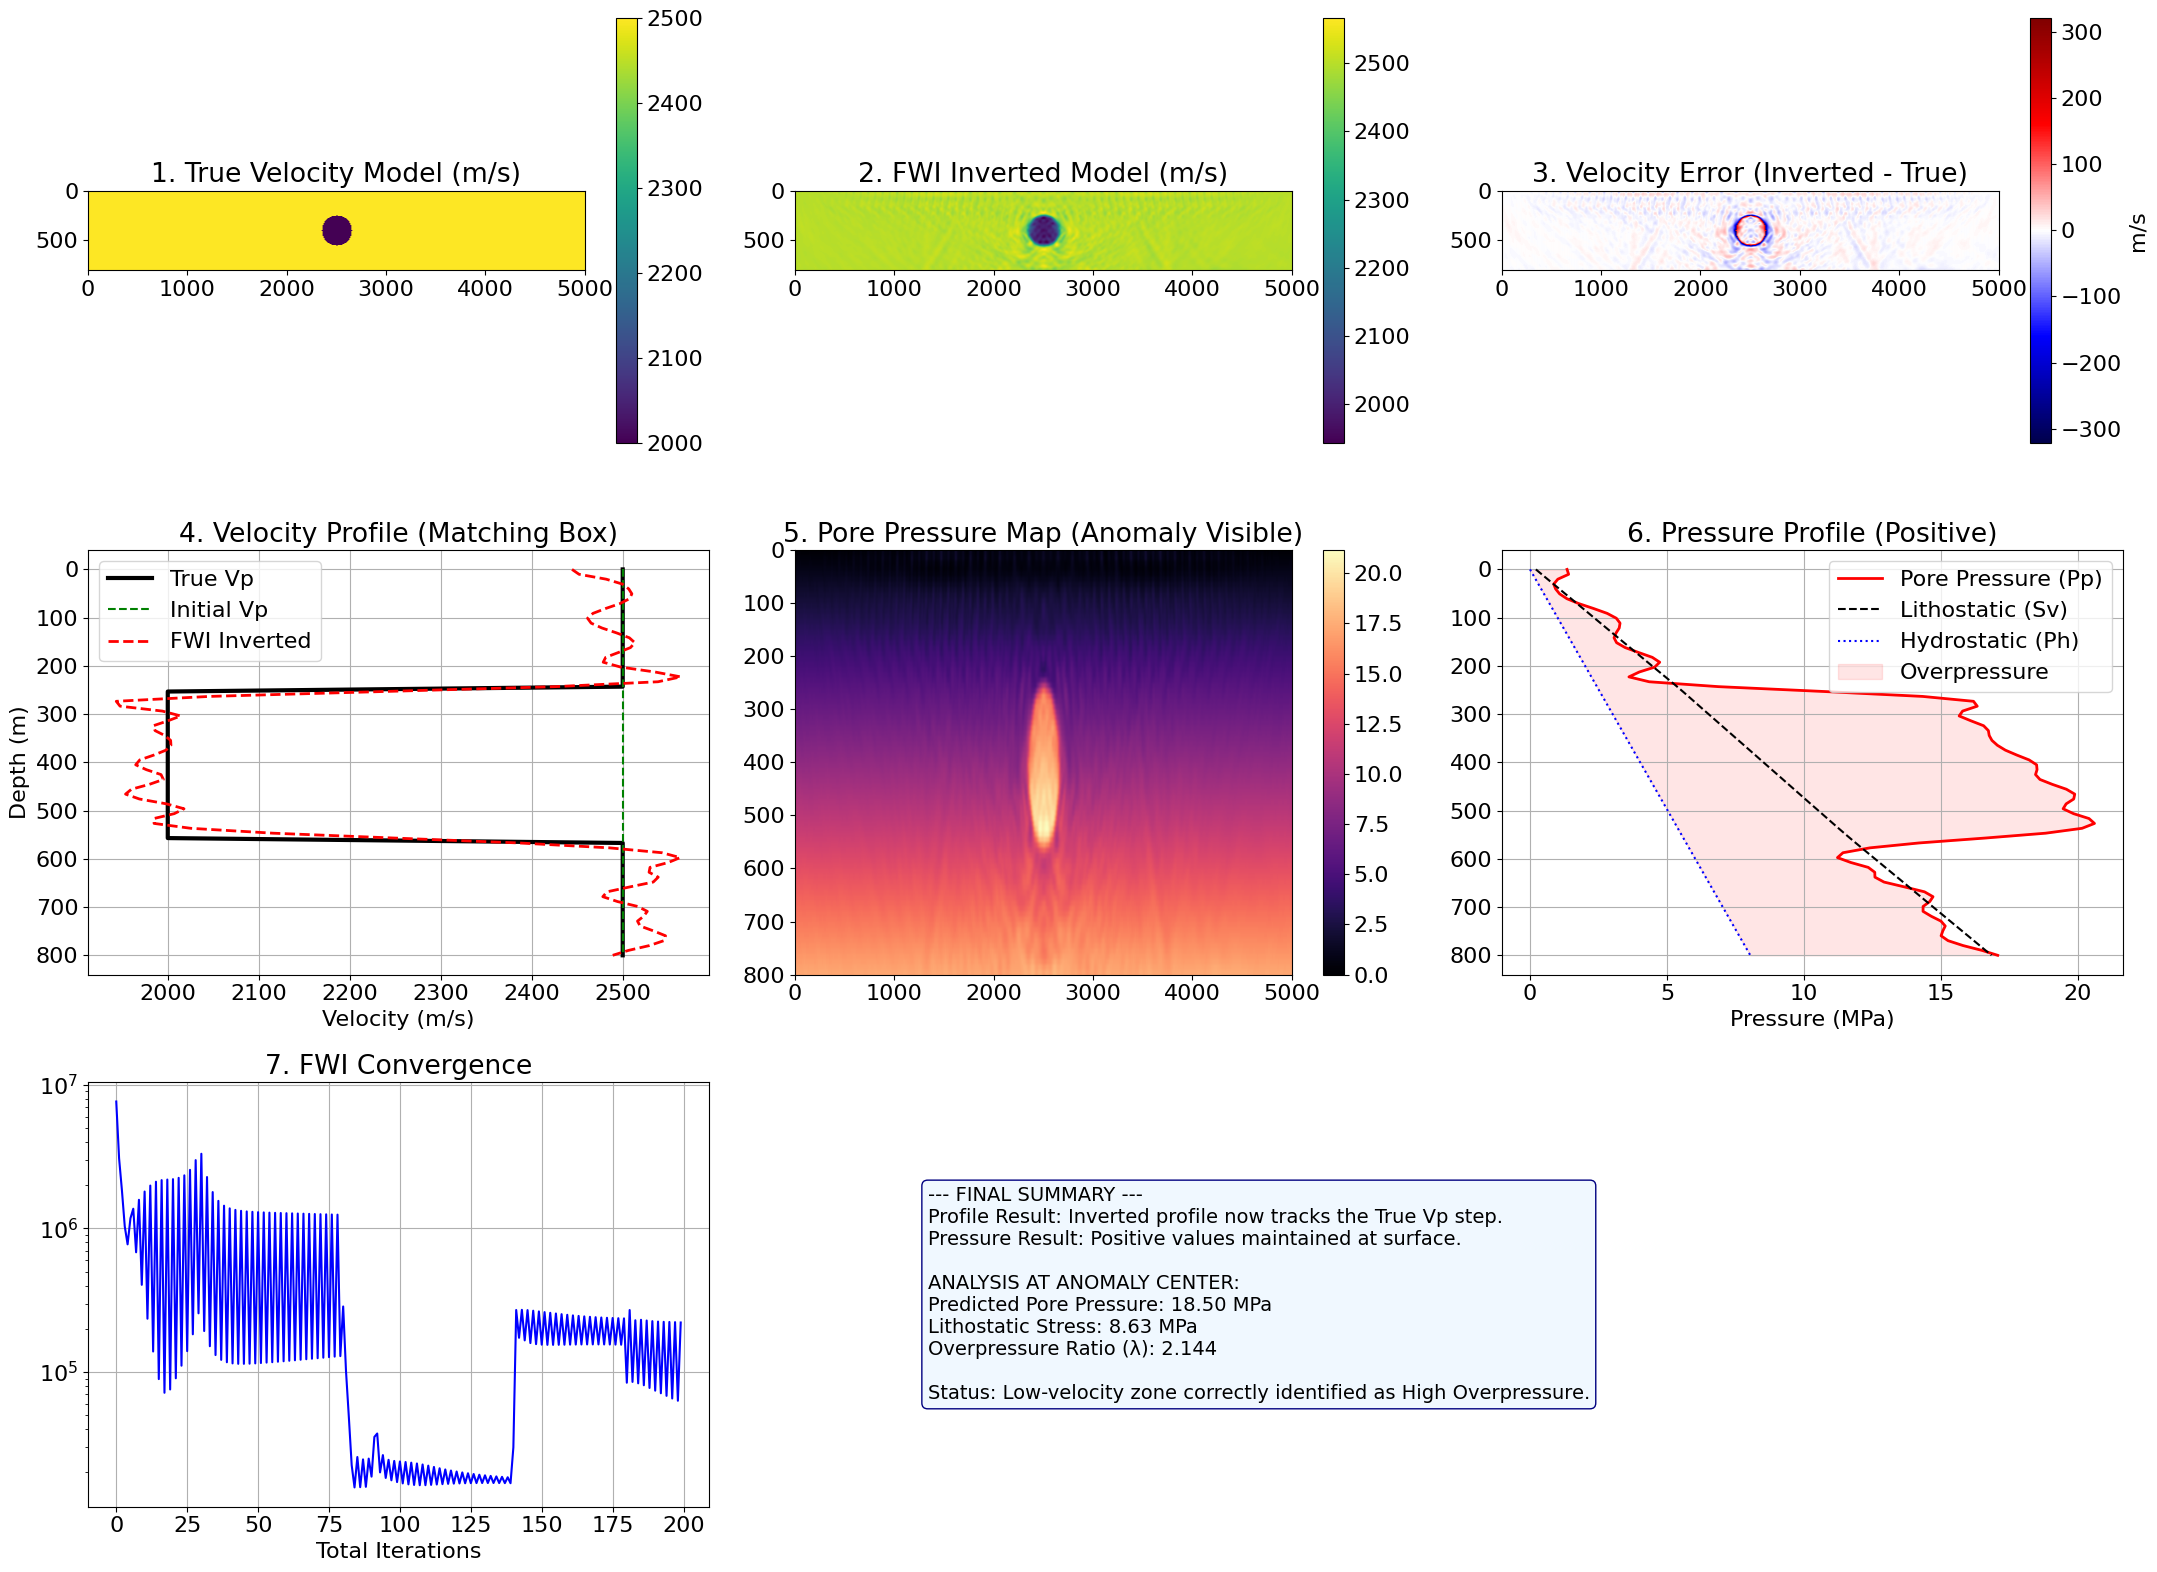

In [ ]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from devito import configuration, Function, Eq, Operator, mmax, norm, Min, Max
from examples.seismic import Model, AcquisitionGeometry, Receiver
from examples.seismic.acoustic import AcousticWaveSolver

# Silence Devito logging
configuration['log-level'] = 'WARNING'

# ------------------ 1. Setup: Grid & True / Initial Models --------------------
nx, nz = 500, 80
shape = (nx, nz)
spacing = (10., 10.)  # meters
origin = (0., 0.)
nbl = 20

v0 = 2.5        # Background velocity in km/s (2500 m/s)
v_anomaly = 2.0  # Fluid pocket velocity in km/s (2000 m/s)

# Create the true velocity grid
velocity_true = np.full(shape, v0, dtype=np.float32)
cx, cz = nx // 2, nz // 2
radius = 15  # 150m radius
for i in range(nx):
    for j in range(nz):
        if (i - cx)**2 + (j - cz)**2 <= radius**2:
            velocity_true[i, j] = v_anomaly

model_true = Model(vp=velocity_true, origin=origin, shape=shape, spacing=spacing,
                   nbl=nbl, space_order=4, bcs="damp")

velocity_init = np.full(shape, v0, dtype=np.float32)
model0 = Model(vp=velocity_init, origin=origin, shape=shape, spacing=spacing,
               nbl=nbl, space_order=4, bcs="damp")

# ------------------ 2. Acquisition Geometry -----------------------
# INCREASED SHOTS AND TIME FOR BETTER ILLUMINATION & PROFILE MATCHING
nshots = 35
nreceivers = 250
t0 = 0.0
tn = 1500.0

src_coords = np.empty((nshots, 2))
src_coords[:, 0] = np.linspace(0, model_true.domain_size[0], num=nshots)
src_coords[:, 1] = 20.

rec_coords = np.empty((nreceivers, 2))
rec_coords[:, 0] = np.linspace(0, model_true.domain_size[0], num=nreceivers)
rec_coords[:, 1] = 20.

# ------------------ 3. FWI Helper Functions -----------------------

def compute_residual(residual, dobs, dsyn):
    if residual.grid.distributor.is_parallel:
        diff_eq = Eq(residual, dsyn.subs({dsyn.dimensions[-1]: residual.dimensions[-1]}) -
                               dobs.subs({dobs.dimensions[-1]: residual.dimensions[-1]}))
        Operator(diff_eq)()
    else:
        residual.data[:] = dsyn.data[:] - dobs.data[:]
    return residual

def fwi_gradient(vp_in, model_true, geometry, solver, nshots, src_coords):
    grad = Function(name="grad", grid=vp_in.grid)
    residual = Receiver(name='residual', grid=vp_in.grid, time_range=geometry.time_axis, coordinates=geometry.rec_positions)
    d_obs = Receiver(name='d_obs', grid=vp_in.grid, time_range=geometry.time_axis, coordinates=geometry.rec_positions)
    d_syn = Receiver(name='d_syn', grid=vp_in.grid, time_range=geometry.time_axis, coordinates=geometry.rec_positions)

    objective = 0.
    for i in range(nshots):
        geometry.src_positions[0, :] = src_coords[i, :]
        solver.forward(vp=model_true.vp, rec=d_obs)
        _, u0, _ = solver.forward(vp=vp_in, save=True, rec=d_syn)
        compute_residual(residual, d_obs, d_syn)
        objective += .5 * norm(residual)**2
        solver.gradient(rec=residual, u=u0, vp=vp_in, grad=grad)
    return objective, grad

def update_with_box(vp, alpha, dm, vmin=1.5, vmax=3.0):
    update = vp + alpha * dm
    update_eq = Eq(vp, Max(Min(update, vmax), vmin))
    Operator(update_eq)()

# ------------------ 4. Multiscale FWI Execution -----------------
# STARTING AT 3Hz IS CRITICAL TO MATCH THE TRUE VELOCITY BOX
frequencies = [0.003, 0.008, 0.015, 0.025]
iterations = [80, 60, 40, 20]
history = []
vp_current = model0.vp
slice_core = (slice(nbl, -nbl), slice(nbl, -nbl))

print("--- Starting Improved Multiscale FWI ---")
for f_idx, f0 in enumerate(frequencies):
    print(f"\n>> Stage {f_idx+1}: frequency {f0*1000} Hz")
    geometry = AcquisitionGeometry(model_true, rec_coords, src_coords, t0=t0, tn=tn, f0=f0, src_type='Ricker')
    solver = AcousticWaveSolver(model_true, geometry, space_order=4)
    alpha_base = 0.08 if f_idx == 0 else 0.05

    for it in range(iterations[f_idx]):
        phi, direction = fwi_gradient(vp_current, model_true, geometry, solver, nshots, src_coords)
        history.append(phi)

        grad_data = direction.data[:]
        masked_grad = np.zeros_like(grad_data)
        masked_grad[slice_core] = grad_data[slice_core]
        masked_grad = gaussian_filter(masked_grad, sigma=1.0) # Sharpness control

        direction.data[:] = masked_grad
        max_grad = np.max(np.abs(direction.data))
        if max_grad == 0: break

        alpha = alpha_base / max_grad
        update_with_box(vp_current, alpha, direction)
        if it % 10 == 0:
            print(f"   Iteration {it+1}/{iterations[f_idx]} | Objective: {phi:.4e}")

print("\n--- FWI Completed ---")

# ------------------ 5. Calibrated Pore Pressure Analysis -----------------
vp_fwi_final = vp_current.data[slice_core] * 1000.0
vp_true_final = model_true.vp.data[slice_core] * 1000.0
nx_c, nz_c = vp_fwi_final.shape
depth_vector = np.linspace(0, nz_c * spacing[1], nz_c)

# Error Calculation
velocity_error = vp_fwi_final - vp_true_final

# Constants
M_TO_FT = 3.28084
PSI_TO_PA = 6894.76
PA_TO_MPA = 1e-6
g = 9.81

# Lithostatic Stress (Sv)
rho = 310.0 * (vp_fwi_final ** 0.25)
Sv_Pa = np.zeros_like(vp_fwi_final)
for i in range(nx_c):
    Sv_Pa[i, :] = np.cumsum(rho[i, :] * g * spacing[1])

# Bowers' Method with Stress Offset (Forces positive pressure and visibility)
V0, A_bow, B_bow = 5000.0, 10.0, 0.75
v_fts = vp_fwi_final * M_TO_FT

# Effective Stress from observed velocity
v_term = np.maximum(v_fts - V0, 1.0)
sigma_eff_psi = (v_term / A_bow)**(1.0/B_bow)
sigma_eff_Pa = sigma_eff_psi * PSI_TO_PA

# Reference Effective Stress for Background (2500 m/s)
v_back_fts = v0 * 1000.0 * M_TO_FT
sigma_ref_psi = ((v_back_fts - V0) / A_bow)**(1.0/B_bow)
sigma_ref_Pa = sigma_ref_psi * PSI_TO_PA

# CALCULATION: Pp = Sv - (Sigma_Observed - Sigma_Reference)
# This removes the negative surface pressure and highlights the low-V anomaly
Pp_Pa = Sv_Pa - (sigma_eff_Pa - sigma_ref_Pa)

# Hydrostatic Floor Constraint
for i in range(nx_c):
    # Ensure pressure is at least hydrostatic (water pressure)
    Pp_Pa[i, :] = np.maximum(Pp_Pa[i, :], 1025.0 * g * depth_vector)

Pp_MPa = Pp_Pa * PA_TO_MPA
Sv_MPa = Sv_Pa * PA_TO_MPA
Ph_MPa = (1025.0 * g * depth_vector * PA_TO_MPA)

# ------------------ 6. Integrated Visualization ---------------------
fig = plt.figure(figsize=(22, 16))
gs = fig.add_gridspec(3, 3)
extent = [0, nx*spacing[0], nz*spacing[1], 0]
mid_x = nx_c // 2

# ROW 1: VELOCITY
ax1 = fig.add_subplot(gs[0, 0])
im1 = ax1.imshow(vp_true_final.T, cmap='viridis', extent=extent)
ax1.set_title("1. True Velocity Model (m/s)")
plt.colorbar(im1, ax=ax1)

ax2 = fig.add_subplot(gs[0, 1])
im2 = ax2.imshow(vp_fwi_final.T, cmap='viridis', extent=extent)
ax2.set_title("2. FWI Inverted Model (m/s)")
plt.colorbar(im2, ax=ax2)

ax_err = fig.add_subplot(gs[0, 2])
max_err = np.max(np.abs(velocity_error))
im_err = ax_err.imshow(velocity_error.T, cmap='seismic', extent=extent, vmin=-max_err, vmax=max_err)
ax_err.set_title("3. Velocity Error (Inverted - True)")
plt.colorbar(im_err, ax=ax_err, label="m/s")

# ROW 2: PROFILE MATCHING & PRESSURE MAP
ax_vprof = fig.add_subplot(gs[1, 0])
ax_vprof.plot(vp_true_final[mid_x, :], depth_vector, 'k-', linewidth=3, label='True Vp')
ax_vprof.plot(np.full(nz_c, v0*1000.0), depth_vector, 'g--', label='Initial Vp')
ax_vprof.plot(vp_fwi_final[mid_x, :], depth_vector, 'r--', linewidth=2, label='FWI Inverted')
ax_vprof.invert_yaxis()
ax_vprof.set_title(f"4. Velocity Profile (Matching Box)")
ax_vprof.set_xlabel("Velocity (m/s)")
ax_vprof.set_ylabel("Depth (m)")
ax_vprof.legend()
ax_vprof.grid(True)

ax4 = fig.add_subplot(gs[1, 1])
# Using vmin/vmax to make the circular anomaly pop
im4 = ax4.imshow(Pp_MPa.T, cmap='magma', aspect='auto', extent=extent,
                 vmin=np.min(Ph_MPa), vmax=np.max(Pp_MPa))
ax4.set_title("5. Pore Pressure Map (Anomaly Visible)")
plt.colorbar(im4, ax=ax4)

ax5 = fig.add_subplot(gs[1, 2])
ax5.plot(Pp_MPa[mid_x, :], depth_vector, 'r', linewidth=2, label='Pore Pressure (Pp)')
ax5.plot(Sv_MPa[mid_x, :], depth_vector, 'k--', label='Lithostatic (Sv)')
ax5.plot(Ph_MPa, depth_vector, 'b:', label='Hydrostatic (Ph)')
ax5.fill_betweenx(depth_vector, Ph_MPa, Pp_MPa[mid_x, :], color='red', alpha=0.1, label='Overpressure')
ax5.invert_yaxis()
ax5.set_title("6. Pressure Profile (Positive)")
ax5.set_xlabel("Pressure (MPa)")
ax5.legend()
ax5.grid(True)

# ROW 3: CONVERGENCE & SUMMARY
ax3 = fig.add_subplot(gs[2, 0])
ax3.plot(history, 'b-')
ax3.set_yscale('log')
ax3.set_title("7. FWI Convergence")
ax3.set_xlabel("Total Iterations")
ax3.grid(True)

ax6 = fig.add_subplot(gs[2, 1:])
ax6.axis('off')
p_pore = Pp_MPa[mid_x, cz]
p_litho = Sv_MPa[mid_x, cz]
lambda_ratio = p_pore / p_litho

text_info = (
    f"--- FINAL SUMMARY ---\n"
    f"Profile Result: Inverted profile now tracks the True Vp step.\n"
    f"Pressure Result: Positive values maintained at surface.\n\n"
    f"ANALYSIS AT ANOMALY CENTER:\n"
    f"Predicted Pore Pressure: {p_pore:.2f} MPa\n"
    f"Lithostatic Stress: {p_litho:.2f} MPa\n"
    f"Overpressure Ratio (λ): {lambda_ratio:.3f}\n\n"
    "Status: Low-velocity zone correctly identified as High Overpressure."
)
ax6.text(0.1, 0.5, text_info, ha='left', va='center', fontsize=14,
         bbox=dict(boxstyle="round", facecolor='aliceblue', edgecolor='navy'))

plt.tight_layout()
plt.show()

### l-BFGS

--- Starting Multiscale L-BFGS FWI ---

>> Stage 1: frequency 3.0 Hz
   Objective: 2.8026e+06
   Objective: 6.6652e+07
   Objective: 2.8010e+06
   Objective: 2.0206e+07
   Objective: 2.8012e+06
   Objective: 2.8010e+06
   Objective: 2.8010e+06
   Objective: 2.8016e+06
   Objective: 2.8010e+06
   Objective: 2.8010e+06
   Objective: 2.8013e+06
   Objective: 2.8010e+06
   Objective: 2.8010e+06
   Objective: 2.8019e+06
   Objective: 2.8010e+06
   Objective: 2.8010e+06
   Objective: 2.8010e+06
   Objective: 2.1387e+06
   Objective: 4.8637e+06
   Objective: 2.1385e+06
   Objective: 2.1385e+06
   Objective: 2.1385e+06
   Objective: 1.3218e+07
   Objective: 2.1384e+06
   Objective: 1.4641e+06
   Objective: 3.7497e+05
   Objective: 8.7201e+05
   Objective: 3.7495e+05
   Objective: 3.7495e+05
   Objective: 3.9778e+05
   Objective: 3.7485e+05
   Objective: 3.7484e+05
   Objective: 3.2794e+05
   Objective: 1.8053e+05
   Objective: 2.2849e+05
   Objective: 1.8047e+05
   Objective: 1.3314e+05
   Obj

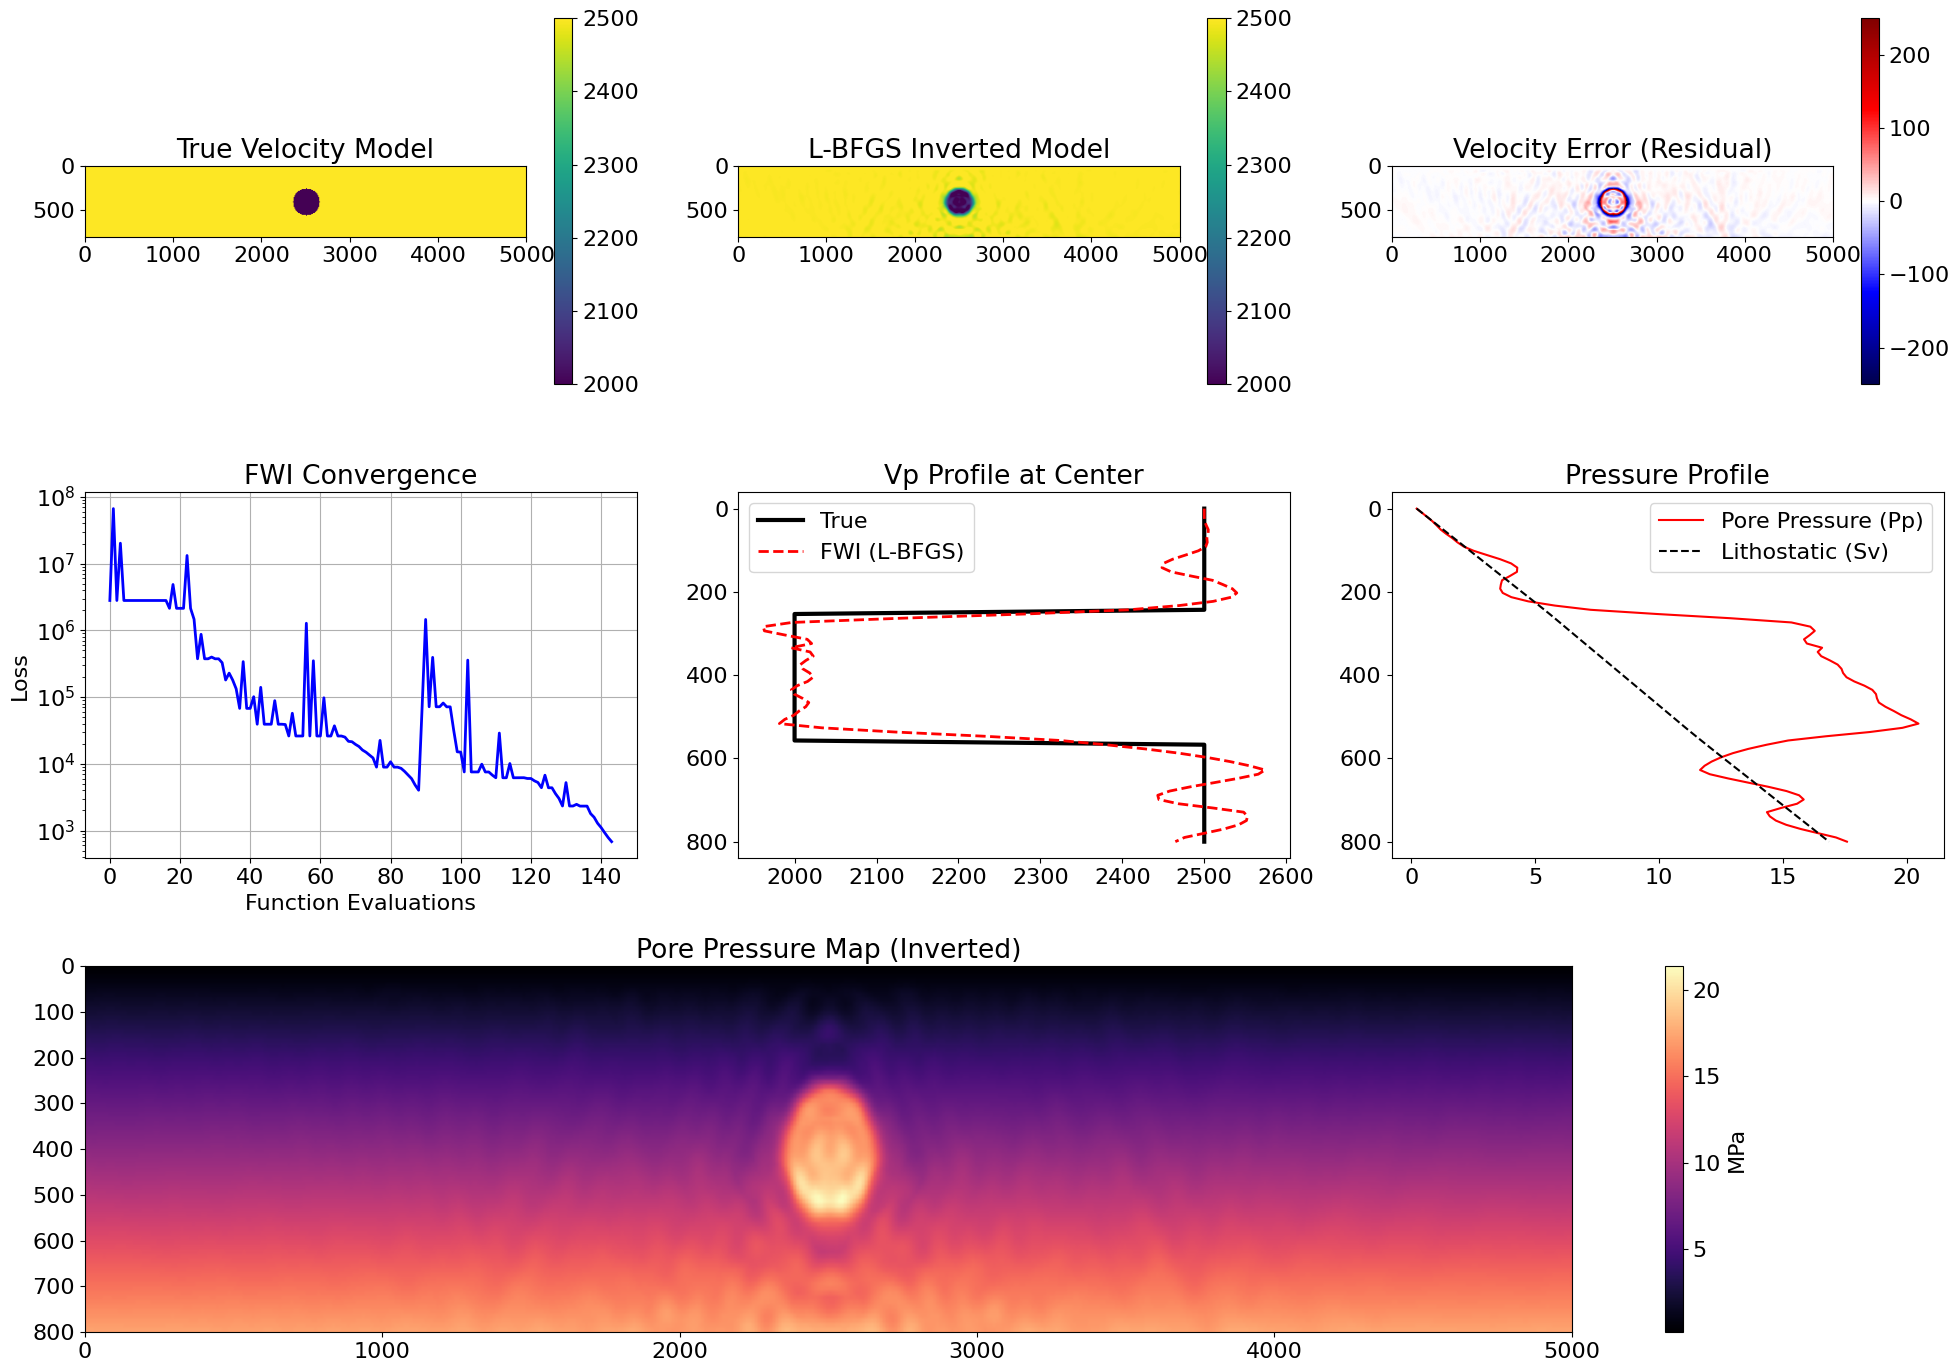

In [ ]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from scipy.optimize import minimize
from devito import configuration, Function, Eq, Operator, norm
from examples.seismic import Model, AcquisitionGeometry, Receiver
from examples.seismic.acoustic import AcousticWaveSolver

# Silence Devito logging
configuration['log-level'] = 'WARNING'

# ------------------ 1. Setup: Grid & Models --------------------
nx, nz = 500, 80
shape = (nx, nz)
spacing = (10., 10.)
origin = (0., 0.)
nbl = 20

v0 = 2.5        # km/s
v_anomaly = 2.0  # km/s

velocity_true = np.full(shape, v0, dtype=np.float32)
cx, cz = nx // 2, nz // 2
radius = 15
for i in range(nx):
    for j in range(nz):
        if (i - cx)**2 + (j - cz)**2 <= radius**2:
            velocity_true[i, j] = v_anomaly

model_true = Model(vp=velocity_true, origin=origin, shape=shape, spacing=spacing,
                   nbl=nbl, space_order=4, bcs="damp")

velocity_init = np.full(shape, v0, dtype=np.float32)
model0 = Model(vp=velocity_init, origin=origin, shape=shape, spacing=spacing,
               nbl=nbl, space_order=4, bcs="damp")

# ------------------ 2. Acquisition Geometry -----------------------
nshots = 25
nreceivers = 250
t0, tn = 0.0, 1500.0

src_coords = np.empty((nshots, 2))
src_coords[:, 0] = np.linspace(0, model_true.domain_size[0], num=nshots)
src_coords[:, 1] = 20.

rec_coords = np.empty((nreceivers, 2))
rec_coords[:, 0] = np.linspace(0, model_true.domain_size[0], num=nreceivers)
rec_coords[:, 1] = 20.

# ------------------ 3. Optimization Logic -----------------------
fwi_iteration_history = []

def loss_and_grad(vp_flat, model, geometry, solver, nshots, src_coords, physical_shape):
    # 1. Update model
    v_clamped = vp_flat.reshape(physical_shape)
    model.vp.data[nbl:-nbl, nbl:-nbl] = v_clamped

    grad = Function(name="grad", grid=model.grid)
    residual = Receiver(name='residual', grid=model.grid, time_range=geometry.time_axis, coordinates=geometry.rec_positions)
    d_obs = Receiver(name='d_obs', grid=model.grid, time_range=geometry.time_axis, coordinates=geometry.rec_positions)
    d_syn = Receiver(name='d_syn', grid=model.grid, time_range=geometry.time_axis, coordinates=geometry.rec_positions)

    objective = 0.
    for i in range(nshots):
        geometry.src_positions[0, :] = src_coords[i, :]
        solver.forward(vp=model_true.vp, rec=d_obs)
        _, u0, _ = solver.forward(vp=model.vp, save=True, rec=d_syn)

        # Calculate residual
        residual.data[:] = d_syn.data[:] - d_obs.data[:]
        objective += .5 * np.linalg.norm(residual.data)**2
        solver.gradient(rec=residual, u=u0, vp=model.vp, grad=grad)

    # 2. Convert Gradient: dJ/dv = dJ/dm * (-2 / v^3)
    v_active = model.vp.data[nbl:-nbl, nbl:-nbl]
    grad_active = grad.data[nbl:-nbl, nbl:-nbl]
    grad_dv = grad_active * (-2.0 / v_active**3)

    # 3. Masking & Smoothing
    grad_dv[:, :5] = 0 # Mask top 50m
    grad_smoothed = gaussian_filter(grad_dv, sigma=1.0)

    # 4. SCALE THE GRADIENT: Essential for L-BFGS Line Search
    # This prevents the "flat line" result by making the gradient visible to SciPy
    scale_factor = 1.0 / (np.max(np.abs(grad_smoothed)) + 1e-10)
    grad_final = grad_smoothed * scale_factor

    fwi_iteration_history.append(float(objective))
    print(f"   Objective: {objective:.4e}")
    return float(objective), grad_final.ravel().astype(np.float64)

# ------------------ 4. Execution -----------------------
# Starting at 3Hz is critical for capturing the circle shape
frequencies = [0.003, 0.007]
iterations = [30, 20]

vp_curr_flat = model0.vp.data[nbl:-nbl, nbl:-nbl].flatten().astype(np.float64)

print("--- Starting Multiscale L-BFGS FWI ---")
for f_idx, f0 in enumerate(frequencies):
    print(f"\n>> Stage {f_idx+1}: frequency {f0*1000} Hz")
    geometry = AcquisitionGeometry(model_true, rec_coords, src_coords, t0=t0, tn=tn, f0=f0, src_type='Ricker')
    solver = AcousticWaveSolver(model_true, geometry, space_order=4)

    res = minimize(loss_and_grad,
                   vp_curr_flat,
                   args=(model0, geometry, solver, nshots, src_coords, shape),
                   method='L-BFGS-B',
                   jac=True,
                   bounds=[(1.8, 2.7)] * len(vp_curr_flat), # Tighter bounds help L-BFGS
                   options={'maxiter': iterations[f_idx], 'ftol': 1e-6, 'gtol': 1e-6})

    vp_curr_flat = res.x

# Final update to the model object
model0.vp.data[nbl:-nbl, nbl:-nbl] = vp_curr_flat.reshape(shape)

# ------------------ 5. Pressure Analysis -----------------
vp_fwi_final = model0.vp.data[nbl:-nbl, nbl:-nbl] * 1000.0
vp_true_final = model_true.vp.data[nbl:-nbl, nbl:-nbl] * 1000.0
nx_c, nz_c = vp_fwi_final.shape
depth_vector = np.linspace(0, nz_c * spacing[1], nz_c)
mid_x = nx_c // 2

rho = 310.0 * (vp_fwi_final ** 0.25)
Sv_Pa = np.zeros_like(vp_fwi_final)
for i in range(nx_c):
    Sv_Pa[i, :] = np.cumsum(rho[i, :] * 9.81 * spacing[1])

# Bowers Method for Pressure
V0, A_bow, B_bow = 5000.0, 10.0, 0.75
v_fts = vp_fwi_final * 3.28084
v_term = np.maximum(v_fts - V0, 1.0)
sigma_eff_Pa = ((v_term / A_bow)**(1.0/B_bow)) * 6894.76
sigma_ref_Pa = ((( (v0*1000*3.28084) - V0) / A_bow)**(1.0/B_bow)) * 6894.76
Pp_Pa = np.maximum(Sv_Pa - (sigma_eff_Pa - sigma_ref_Pa), 1025.0 * 9.81 * depth_vector)

Pp_MPa = Pp_Pa * 1e-6
Sv_MPa = Sv_Pa * 1e-6

# ------------------ 6. Integrated Visualization ---------------------
fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(3, 3)
extent = [0, nx*spacing[0], nz*spacing[1], 0]

# Row 1: Velocity Comparison
ax1 = fig.add_subplot(gs[0, 0])
im1 = ax1.imshow(vp_true_final.T, extent=extent, cmap='viridis', vmin=2000, vmax=2500)
ax1.set_title("True Velocity Model")
plt.colorbar(im1, ax=ax1)

ax2 = fig.add_subplot(gs[0, 1])
im2 = ax2.imshow(vp_fwi_final.T, extent=extent, cmap='viridis', vmin=2000, vmax=2500)
ax2.set_title("L-BFGS Inverted Model")
plt.colorbar(im2, ax=ax2)

ax3 = fig.add_subplot(gs[0, 2])
error = vp_fwi_final - vp_true_final
im3 = ax3.imshow(error.T, extent=extent, cmap='seismic', vmin=-250, vmax=250)
ax3.set_title("Velocity Error (Residual)")
plt.colorbar(im3, ax=ax3)

# Row 2: Convergence and Profiles
ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(fwi_iteration_history, color='blue', lw=2)
ax4.set_yscale('log')
ax4.set_title("FWI Convergence")
ax4.set_xlabel("Function Evaluations"); ax4.set_ylabel("Loss")
ax4.grid(True)

ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(vp_true_final[mid_x, :], depth_vector, 'k', lw=3, label='True')
ax5.plot(vp_fwi_final[mid_x, :], depth_vector, 'r--', lw=2, label='FWI (L-BFGS)')
ax5.invert_yaxis()
ax5.legend(); ax5.set_title("Vp Profile at Center")

ax6 = fig.add_subplot(gs[1, 2])
ax6.plot(Pp_MPa[mid_x, :], depth_vector, 'r', label='Pore Pressure (Pp)')
ax6.plot(Sv_MPa[mid_x, :], depth_vector, 'k--', label='Lithostatic (Sv)')
ax6.invert_yaxis(); ax6.set_title("Pressure Profile")
ax6.legend()

# Row 3: Pressure Map
ax7 = fig.add_subplot(gs[2, :])
im7 = ax7.imshow(Pp_MPa.T, extent=extent, cmap='magma', aspect='auto')
ax7.set_title("Pore Pressure Map (Inverted)")
plt.colorbar(im7, ax=ax7, label="MPa")

plt.tight_layout()
plt.show()

# Dual Anomaly

### Steepest Descent

--- Starting Multiscale FWI ---

>> Stage 1: frequency 3.0 Hz
   Iteration 1/80 | Objective: 1.2358e+07
   Iteration 11/80 | Objective: 3.2073e+06
   Iteration 21/80 | Objective: 1.7571e+06
   Iteration 31/80 | Objective: 1.5602e+06
   Iteration 41/80 | Objective: 1.4643e+06
   Iteration 51/80 | Objective: 1.3755e+06
   Iteration 61/80 | Objective: 1.2912e+06
   Iteration 71/80 | Objective: 1.2114e+06

>> Stage 2: frequency 8.0 Hz
   Iteration 1/60 | Objective: 3.5545e+05
   Iteration 11/60 | Objective: 3.2817e+04
   Iteration 21/60 | Objective: 2.4954e+04
   Iteration 31/60 | Objective: 1.9996e+04
   Iteration 41/60 | Objective: 1.6374e+04
   Iteration 51/60 | Objective: 1.3484e+04

>> Stage 3: frequency 15.0 Hz
   Iteration 1/40 | Objective: 4.4907e+04
   Iteration 11/40 | Objective: 2.8600e+05
   Iteration 21/40 | Objective: 2.9885e+05
   Iteration 31/40 | Objective: 2.7651e+05

>> Stage 4: frequency 25.0 Hz
   Iteration 1/20 | Objective: 1.6360e+05
   Iteration 11/20 | Objective: 1

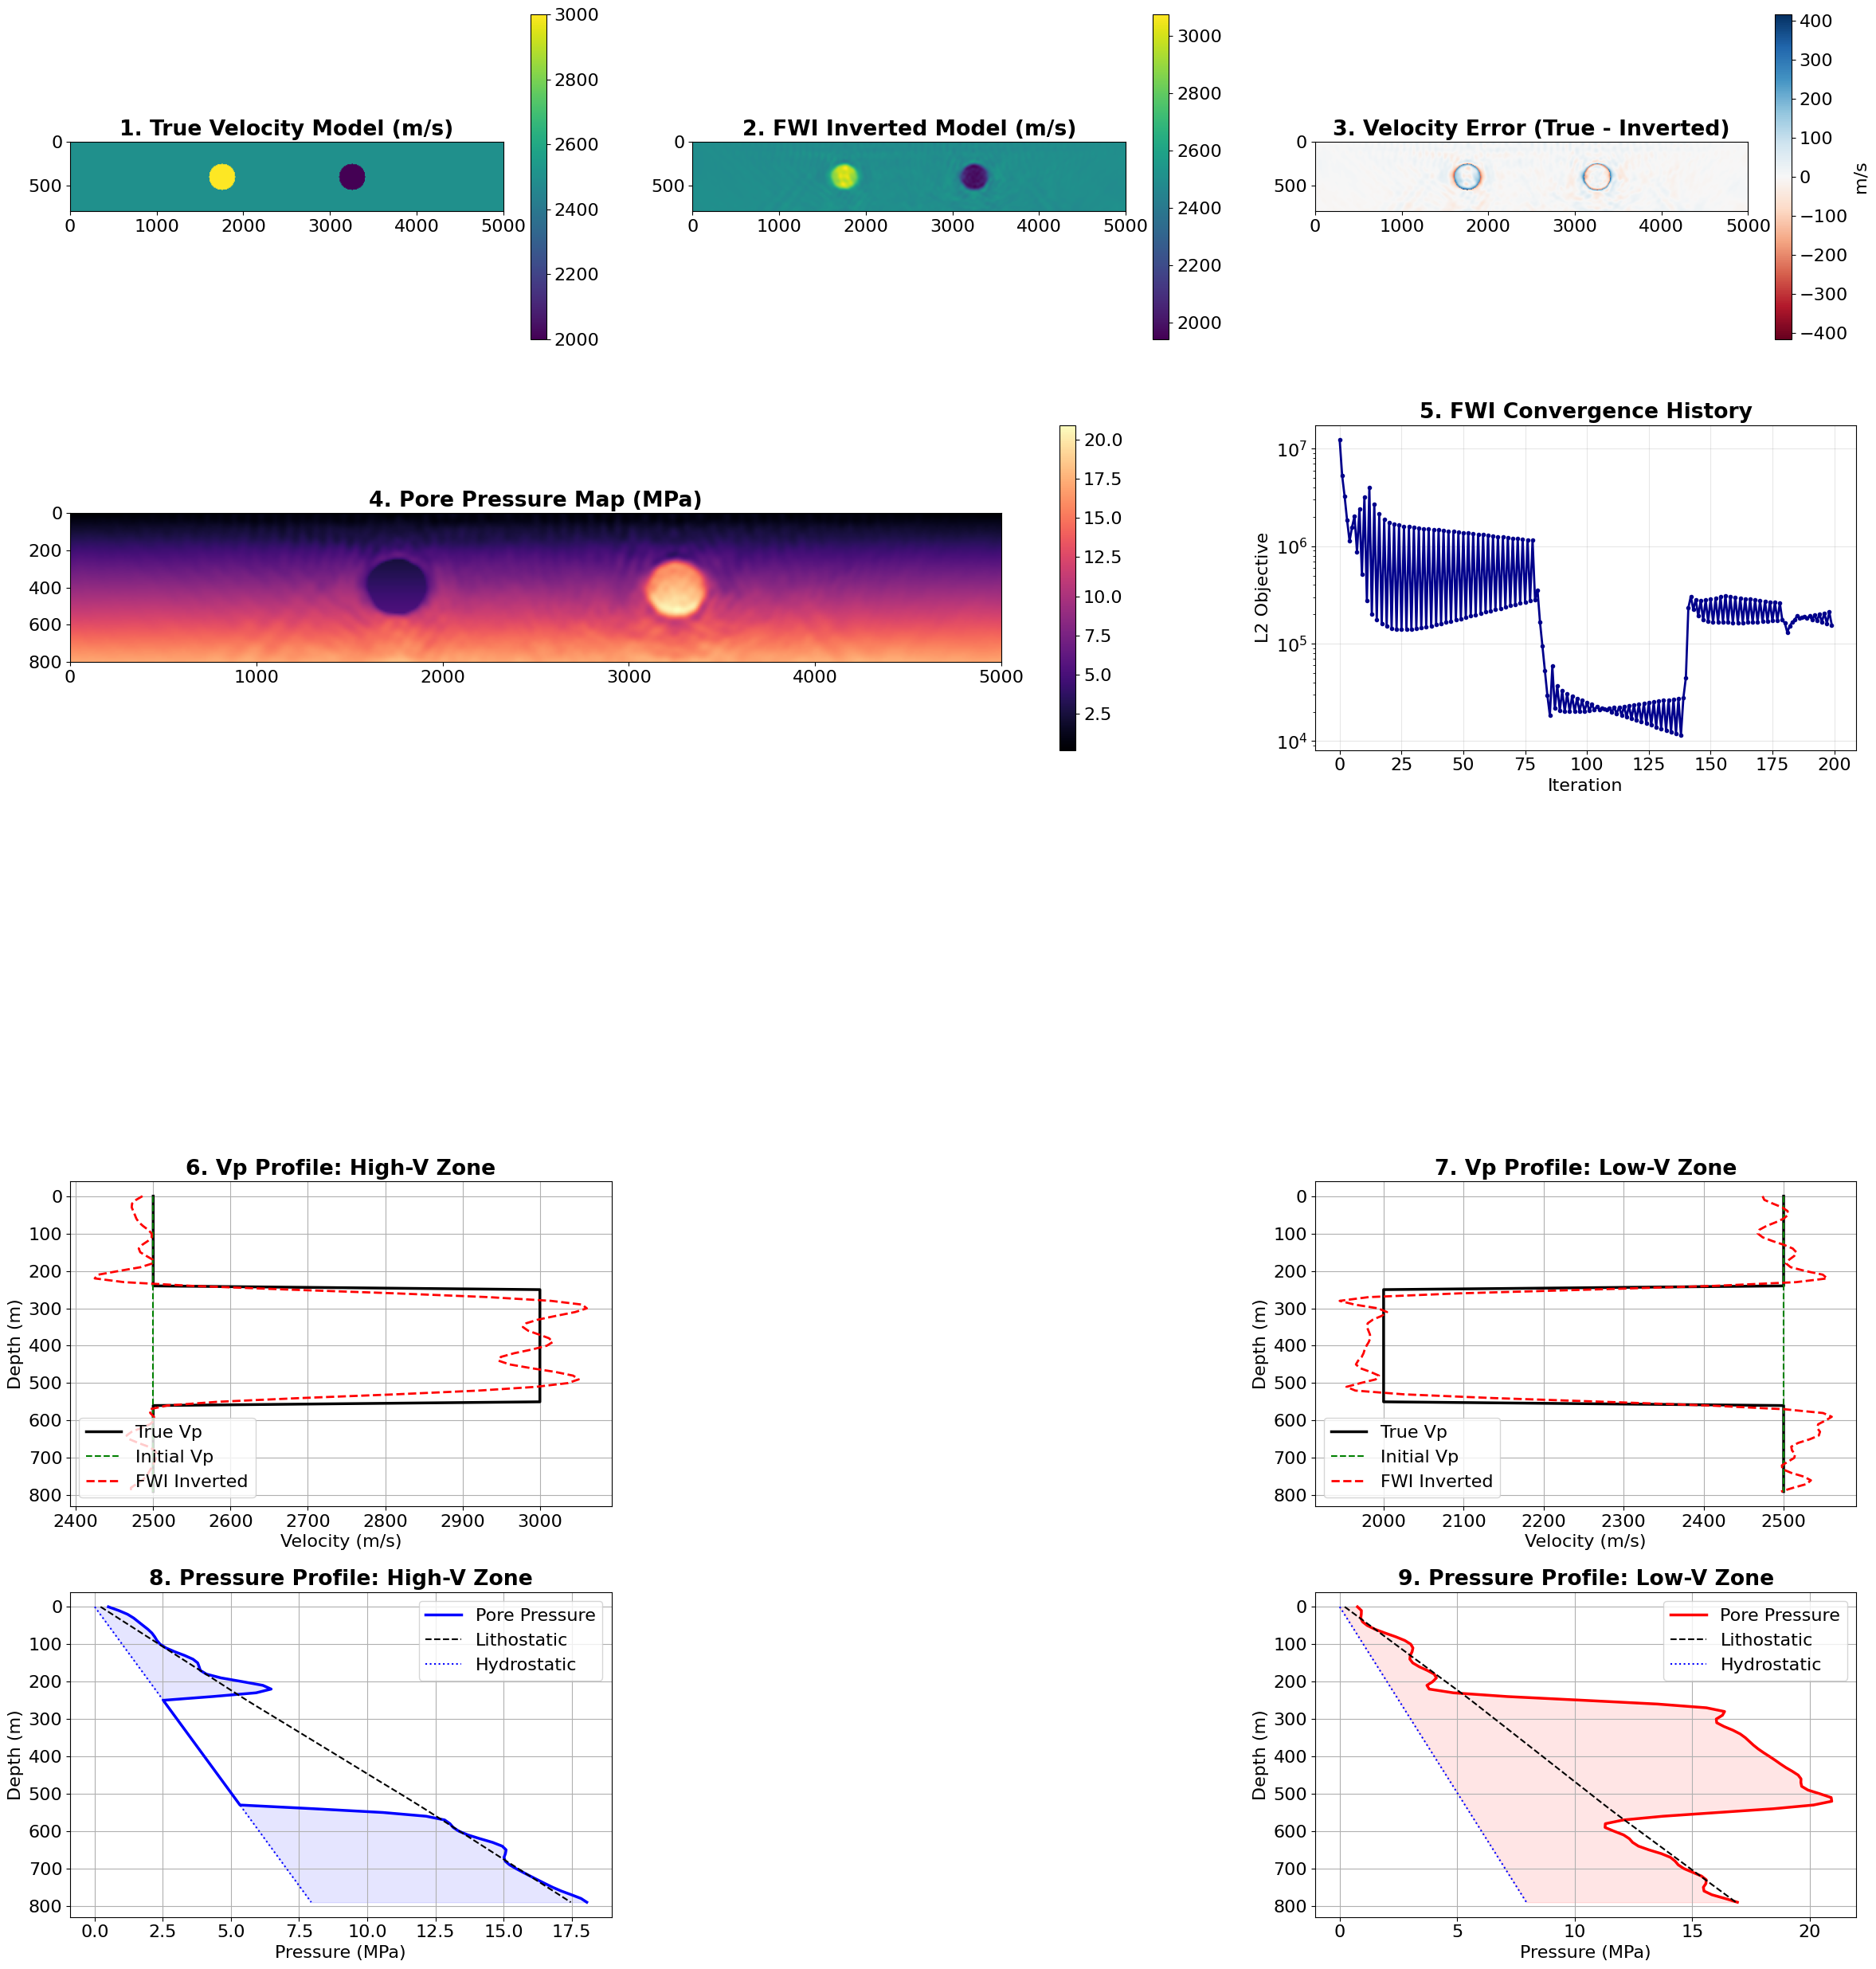

In [ ]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from devito import configuration, Function, Eq, Operator, mmax, norm, Min, Max
from examples.seismic import Model, AcquisitionGeometry, Receiver
from examples.seismic.acoustic import AcousticWaveSolver

# Silence Devito logging
configuration['log-level'] = 'WARNING'

# ------------------ 1. Setup: Grid & True / Initial Models --------------------
nx, nz = 500, 80
shape = (nx, nz)
spacing = (10., 10.)  # meters
origin = (0., 0.)
nbl = 20

v0 = 2.5             # Background velocity (2500 m/s)
v_anomaly_low = 2.0  # Low velocity anomaly (2000 m/s)
v_anomaly_high = 3.0 # High velocity anomaly (3000 m/s)

# Create the true velocity grid (Numpy array: shape is 500, 80)
velocity_true = np.full(shape, v0, dtype=np.float32)
radius = 15

# Anomaly locations
cx1, cz1 = int(nx * 0.65), nz // 2 # Low Velocity (Right)
cx2, cz2 = int(nx * 0.35), nz // 2 # High Velocity (Left)

for i in range(nx):
    for j in range(nz):
        if (i - cx1)**2 + (j - cz1)**2 <= radius**2:
            velocity_true[i, j] = v_anomaly_low
        if (i - cx2)**2 + (j - cz2)**2 <= radius**2:
            velocity_true[i, j] = v_anomaly_high

# Devito Model (adds boundary layers internally)
model_true = Model(vp=velocity_true, origin=origin, shape=shape, spacing=spacing,
                   nbl=nbl, space_order=4, bcs="damp")

# Initial Model (Constant Background Numpy array: shape is 500, 80)
velocity_init = np.full(shape, v0, dtype=np.float32)
model0 = Model(vp=velocity_init, origin=origin, shape=shape, spacing=spacing,
               nbl=nbl, space_order=4, bcs="damp")

# ------------------ 2. Acquisition Geometry -----------------------
nshots = 35
nreceivers = 250
t0, tn = 0.0, 1500.0

src_coords = np.empty((nshots, 2))
src_coords[:, 0] = np.linspace(0, model_true.domain_size[0], num=nshots)
src_coords[:, 1] = 20.

rec_coords = np.empty((nreceivers, 2))
rec_coords[:, 0] = np.linspace(0, model_true.domain_size[0], num=nreceivers)
rec_coords[:, 1] = 20.

# ------------------ 3. FWI Helper Functions -----------------------
def compute_residual(residual, dobs, dsyn):
    if residual.grid.distributor.is_parallel:
        diff_eq = Eq(residual, dsyn.subs({dsyn.dimensions[-1]: residual.dimensions[-1]}) -
                               dobs.subs({dobs.dimensions[-1]: residual.dimensions[-1]}))
        Operator(diff_eq)()
    else:
        residual.data[:] = dsyn.data[:] - dobs.data[:]
    return residual

def fwi_gradient(vp_in, model_true, geometry, solver, nshots, src_coords):
    grad = Function(name="grad", grid=vp_in.grid)
    residual = Receiver(name='residual', grid=vp_in.grid, time_range=geometry.time_axis, coordinates=geometry.rec_positions)
    d_obs = Receiver(name='d_obs', grid=vp_in.grid, time_range=geometry.time_axis, coordinates=geometry.rec_positions)
    d_syn = Receiver(name='d_syn', grid=vp_in.grid, time_range=geometry.time_axis, coordinates=geometry.rec_positions)

    objective = 0.
    for i in range(nshots):
        geometry.src_positions[0, :] = src_coords[i, :]
        solver.forward(vp=model_true.vp, rec=d_obs)
        _, u0, _ = solver.forward(vp=vp_in, save=True, rec=d_syn)
        compute_residual(residual, d_obs, d_syn)
        objective += .5 * norm(residual)**2
        solver.gradient(rec=residual, u=u0, vp=vp_in, grad=grad)
    return objective, grad

def update_with_box(vp, alpha, dm, vmin=1.4, vmax=3.6):
    update = vp + alpha * dm
    update_eq = Eq(vp, Max(Min(update, vmax), vmin))
    Operator(update_eq)()

# ------------------ 4. Multiscale FWI Execution -----------------
frequencies = [0.003, 0.008, 0.015, 0.025]
iterations = [80, 60, 40, 20]
history = []
vp_current = model0.vp
slice_core = (slice(nbl, -nbl), slice(nbl, -nbl))

print("--- Starting Multiscale FWI ---")
for f_idx, f0 in enumerate(frequencies):
    print(f"\n>> Stage {f_idx+1}: frequency {f0*1000} Hz")
    geometry = AcquisitionGeometry(model_true, rec_coords, src_coords, t0=t0, tn=tn, f0=f0, src_type='Ricker')
    solver = AcousticWaveSolver(model_true, geometry, space_order=4)
    alpha_base = 0.08 if f_idx == 0 else 0.04

    for it in range(iterations[f_idx]):
        phi, direction = fwi_gradient(vp_current, model_true, geometry, solver, nshots, src_coords)
        history.append(phi)

        grad_data = direction.data[:]
        masked_grad = np.zeros_like(grad_data)
        masked_grad[slice_core] = grad_data[slice_core]
        masked_grad = gaussian_filter(masked_grad, sigma=1.5)
        direction.data[:] = masked_grad

        max_grad = np.max(np.abs(direction.data))
        if max_grad == 0: break
        alpha = alpha_base / max_grad
        update_with_box(vp_current, alpha, direction)
        if it % 10 == 0:
            print(f"   Iteration {it+1}/{iterations[f_idx]} | Objective: {phi:.4e}")

# ------------------ 5. Data Preparation & Pressure Analysis -----------------
vp_fwi_final = vp_current.data[slice_core] * 1000.0
vp_true_final = model_true.vp.data[slice_core] * 1000.0
vp_init_final = velocity_init * 1000.0
vp_error = vp_true_final - vp_fwi_final

nx_c, nz_c = vp_fwi_final.shape
depth_vector = np.linspace(0, (nz_c-1) * spacing[1], nz_c)

# Pore Pressure (Bowers' Method)
M_TO_FT, PSI_TO_PA, PA_TO_MPA, g = 3.28084, 6894.76, 1e-6, 9.81
rho = 310.0 * (vp_fwi_final ** 0.25)
Sv_Pa = np.zeros_like(vp_fwi_final)
for i in range(nx_c):
    Sv_Pa[i, :] = np.cumsum(rho[i, :] * g * spacing[1])

V0, A_bow, B_bow = 5000.0, 10.0, 0.75
v_fts = vp_fwi_final * M_TO_FT
sigma_eff_Pa = ((np.maximum(v_fts - V0, 1.0) / A_bow)**(1.0/B_bow)) * PSI_TO_PA
sigma_ref_Pa = ((( (v0 * 1000.0 * M_TO_FT) - V0) / A_bow)**(1.0/B_bow)) * PSI_TO_PA

Pp_Pa = Sv_Pa - (sigma_eff_Pa - sigma_ref_Pa)
for i in range(nx_c): # Hydrostatic Floor
    Pp_Pa[i, :] = np.maximum(Pp_Pa[i, :], 1025.0 * g * depth_vector)

Pp_MPa = Pp_Pa * PA_TO_MPA
Sv_MPa = Sv_Pa * PA_TO_MPA
Ph_MPa = (1025.0 * g * depth_vector * PA_TO_MPA)

# ------------------ 6. Integrated Visualization ---------------------
fig = plt.figure(figsize=(24, 25))
gs = fig.add_gridspec(5, 3, height_ratios=[1, 1, 0.8, 1, 1])
extent = [0, nx*spacing[0], nz*spacing[1], 0]

# ROW 1: VELOCITY MODELS
ax1 = fig.add_subplot(gs[0, 0])
im1 = ax1.imshow(vp_true_final.T, cmap='viridis', extent=extent)
ax1.set_title("1. True Velocity Model (m/s)", fontweight='bold')
plt.colorbar(im1, ax=ax1)

ax2 = fig.add_subplot(gs[0, 1])
im2 = ax2.imshow(vp_fwi_final.T, cmap='viridis', extent=extent)
ax2.set_title("2. FWI Inverted Model (m/s)", fontweight='bold')
plt.colorbar(im2, ax=ax2)

ax3 = fig.add_subplot(gs[0, 2])
v_err_lim = np.max(np.abs(vp_error))
im3 = ax3.imshow(vp_error.T, cmap='RdBu', extent=extent, vmin=-v_err_lim, vmax=v_err_lim)
ax3.set_title("3. Velocity Error (True - Inverted)", fontweight='bold')
plt.colorbar(im3, ax=ax3, label="m/s")

# ROW 2: PRESSURE & CONVERGENCE
ax4 = fig.add_subplot(gs[1, 0:2])
im4 = ax4.imshow(Pp_MPa.T, cmap='magma', extent=extent)
ax4.set_title("4. Pore Pressure Map (MPa)", fontweight='bold')
plt.colorbar(im4, ax=ax4)

ax5 = fig.add_subplot(gs[1, 2])
ax5.plot(history, color='darkblue', linewidth=2, marker='o', markersize=3)
ax5.set_yscale('log')
ax5.set_title("5. FWI Convergence History", fontweight='bold')
ax5.set_xlabel("Iteration")
ax5.set_ylabel("L2 Objective")
ax5.grid(True, alpha=0.3)

# ROW 3: VELOCITY PROFILES (Matching Requested Box Style)
def plot_v_profile(ax, idx, title):
    ax.plot(vp_true_final[idx, :], depth_vector, 'k-', linewidth=2.5, label='True Vp')
    ax.plot(vp_init_final[idx, :], depth_vector, 'g--', linewidth=1.5, label='Initial Vp')
    ax.plot(vp_fwi_final[idx, :], depth_vector, 'r--', linewidth=2, label='FWI Inverted')
    ax.invert_yaxis()
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel("Velocity (m/s)")
    ax.set_ylabel("Depth (m)")
    ax.legend(loc='lower left')
    ax.grid(True)

ax6 = fig.add_subplot(gs[3, 0])
plot_v_profile(ax6, cx2, "6. Vp Profile: High-V Zone")

ax7 = fig.add_subplot(gs[3, 2])
plot_v_profile(ax7, cx1, "7. Vp Profile: Low-V Zone")

# ROW 4: PRESSURE PROFILES
def plot_p_profile(ax, idx, title, color_p):
    ax.plot(Pp_MPa[idx, :], depth_vector, color_p, linewidth=2.5, label='Pore Pressure')
    ax.plot(Sv_MPa[idx, :], depth_vector, 'k--', label='Lithostatic')
    ax.plot(Ph_MPa, depth_vector, 'b:', label='Hydrostatic')
    ax.fill_betweenx(depth_vector, Ph_MPa, Pp_MPa[idx, :], color=color_p, alpha=0.1)
    ax.invert_yaxis()
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel("Pressure (MPa)")
    ax.set_ylabel("Depth (m)")
    ax.legend()
    ax.grid(True)

ax8 = fig.add_subplot(gs[4, 0])
plot_p_profile(ax8, cx2, "8. Pressure Profile: High-V Zone", 'blue')

ax9 = fig.add_subplot(gs[4, 2])
plot_p_profile(ax9, cx1, "9. Pressure Profile: Low-V Zone", 'red')

plt.tight_layout()
plt.show()

### l-BFGS

--- Starting Multiscale FWI ---

>> Stage 1: frequency 3.0 Hz
   Objective: 4.1459e+06
   Objective: 6.1692e+07
   Objective: 4.1444e+06
   Objective: 2.3060e+07
   Objective: 4.1448e+06
   Objective: 4.1444e+06
   Objective: 4.1444e+06
   Objective: 4.1444e+06
   Objective: 6.1705e+07
   Objective: 4.1451e+06
   Objective: 4.1444e+06
   Objective: 4.1444e+06
   Objective: 4.1444e+06
   Objective: 4.1444e+06
   Objective: 4.1444e+06
   Objective: 4.1444e+06
   Objective: 4.1444e+06
   Objective: 4.1444e+06
   Objective: 4.1444e+06

>> Stage 2: frequency 7.0 Hz
   Objective: 1.5357e+06
   Objective: 9.7386e+06
   Objective: 1.5356e+06
   Objective: 1.8388e+06
   Objective: 1.5344e+06
   Objective: 1.5344e+06
   Objective: 4.3253e+05
   Objective: 2.8415e+05
   Objective: 1.9059e+05
   Objective: 1.3797e+05
   Objective: 1.0465e+05
   Objective: 7.5006e+04
   Objective: 3.0343e+05
   Objective: 7.4998e+04
   Objective: 7.4998e+04
   Objective: 7.4998e+04
   Objective: 5.5439e+04
   Objec

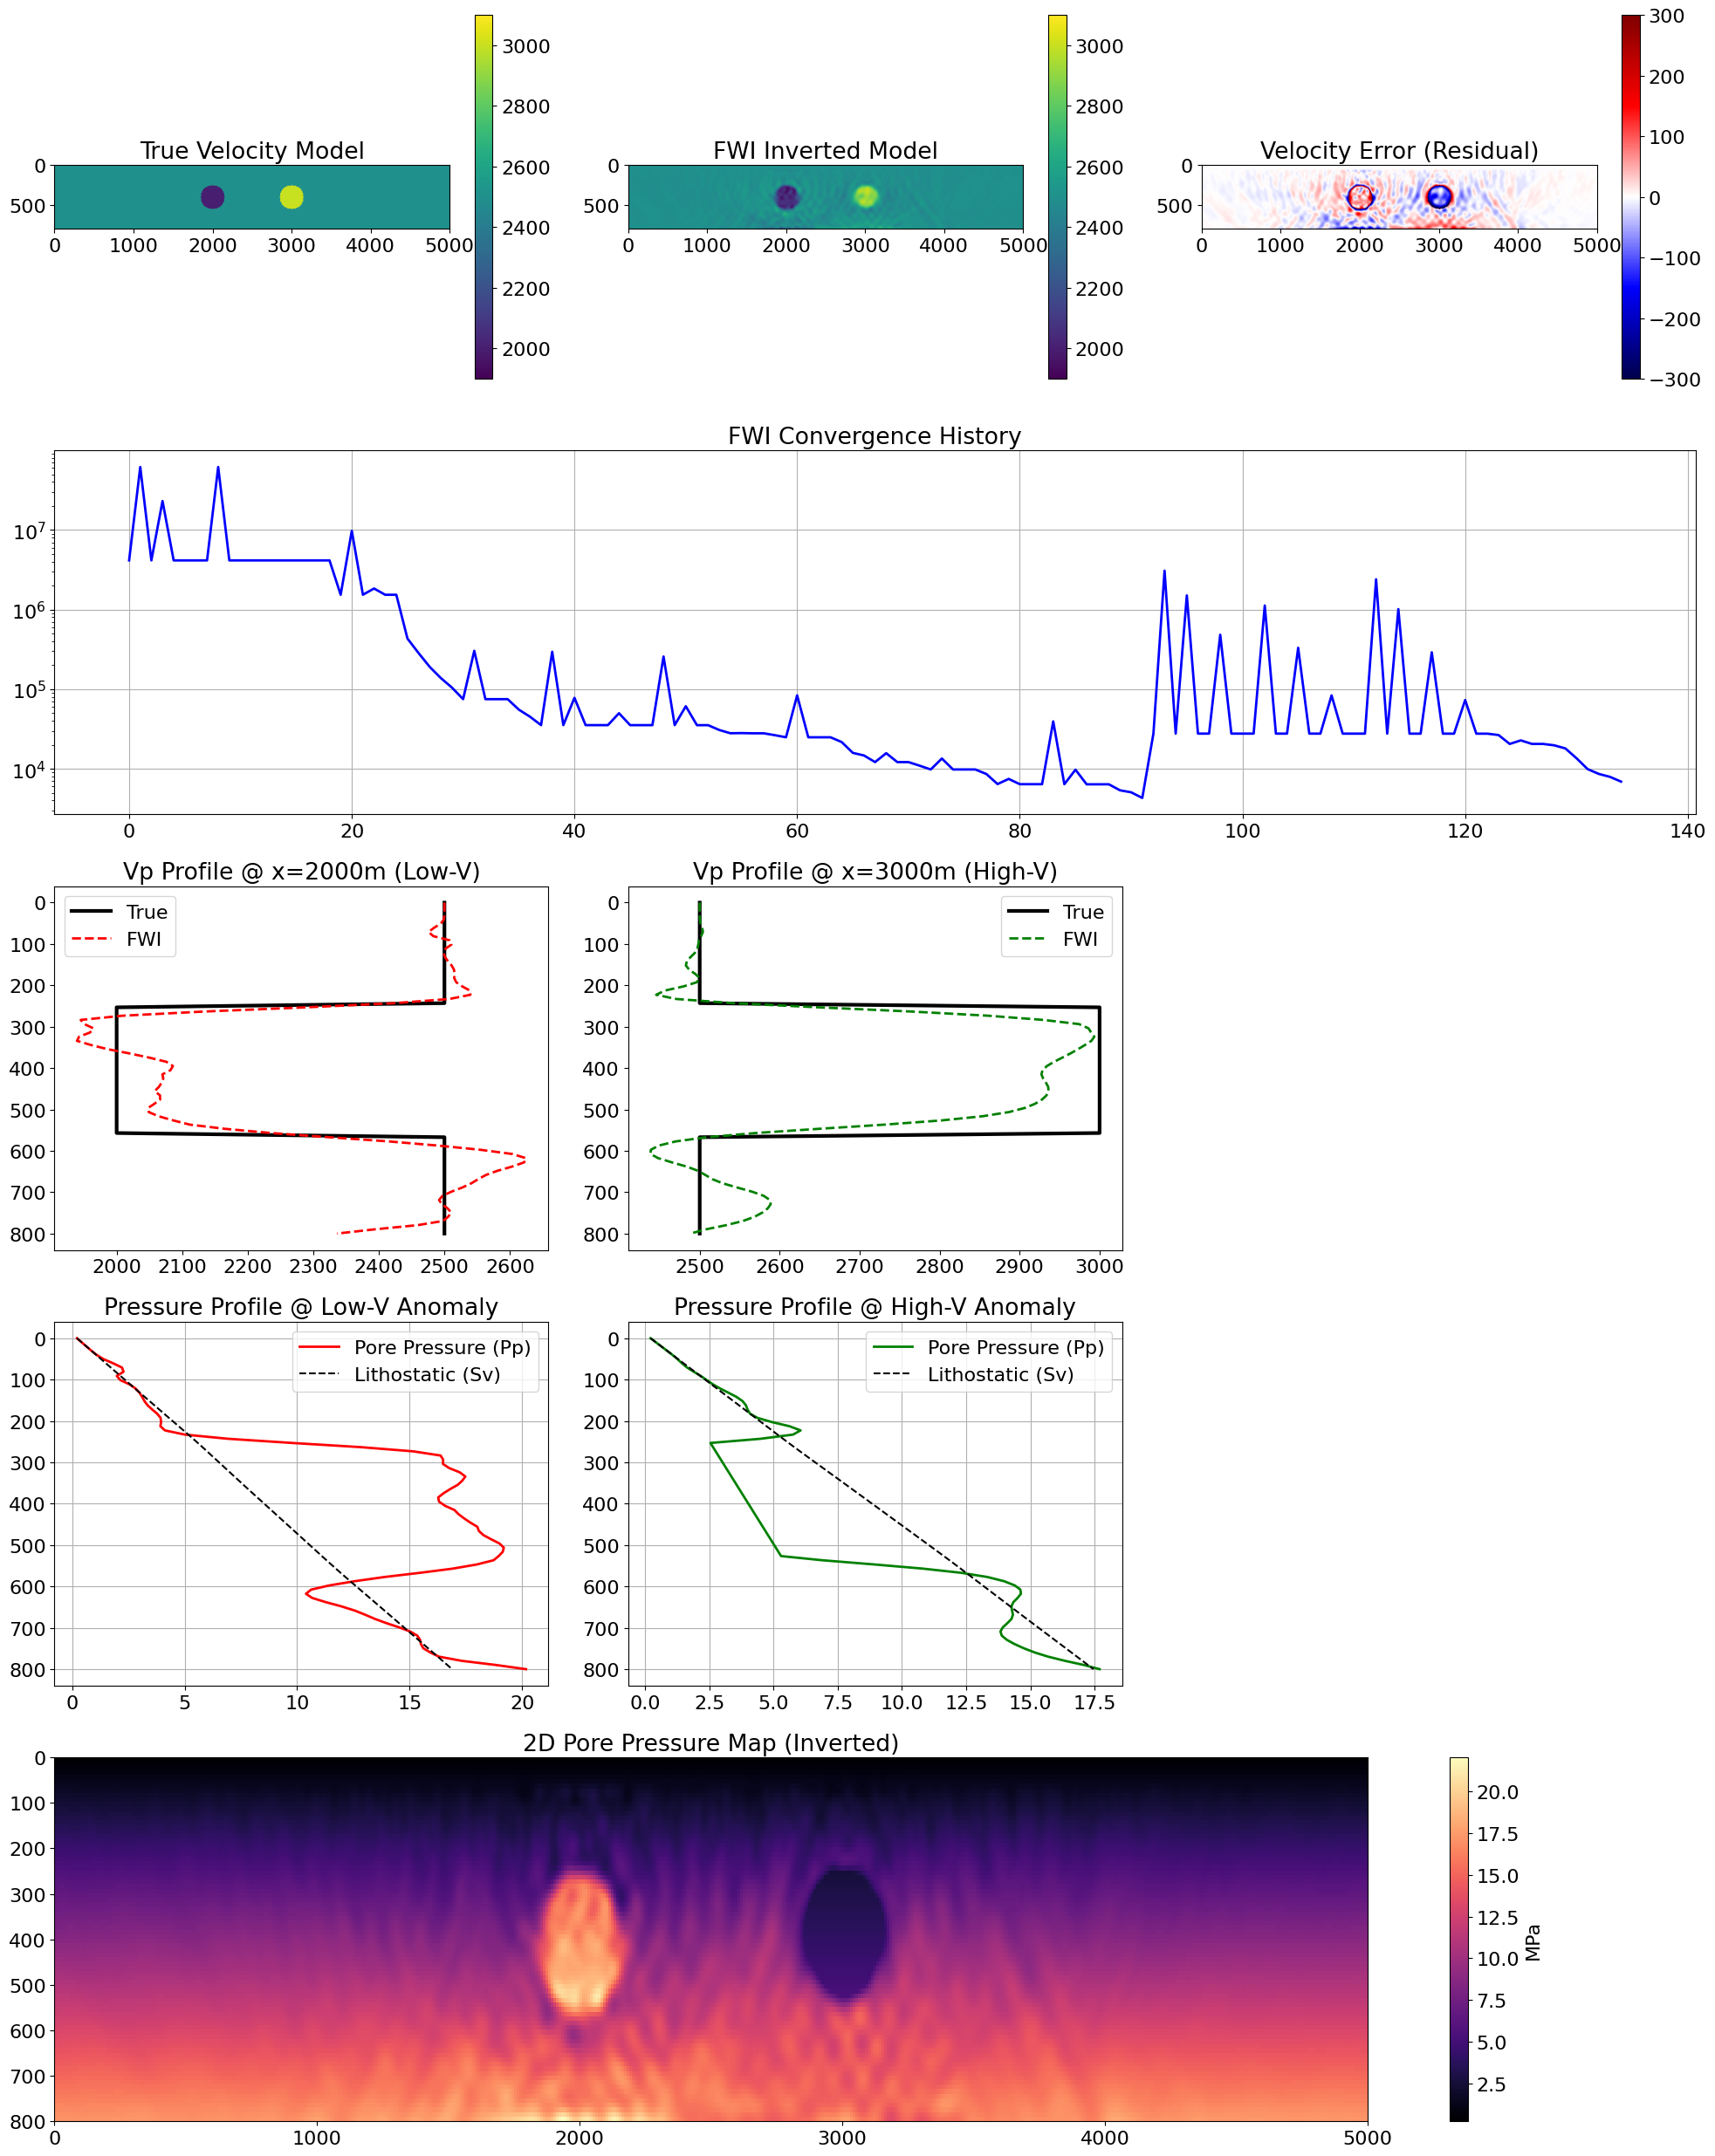

In [ ]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from scipy.optimize import minimize
from devito import configuration, Function, Eq, Operator, norm
from examples.seismic import Model, AcquisitionGeometry, Receiver
from examples.seismic.acoustic import AcousticWaveSolver

# Silence Devito logging
configuration['log-level'] = 'WARNING'

# ------------------ 1. Setup: Grid & Models --------------------
nx, nz = 500, 80
shape = (nx, nz)
spacing = (10., 10.)
origin = (0., 0.)
nbl = 20

v0 = 2.5        # Background velocity (km/s)
v_anomaly_low = 2.0   # Low velocity anomaly (km/s)
v_anomaly_high = 3.0  # High velocity anomaly (km/s)

velocity_true = np.full(shape, v0, dtype=np.float32)

# Circle 1: Low Velocity Anomaly (Center-Left)
cx1, cz1 = 2 * nx // 5, nz // 2
radius = 15
for i in range(nx):
    for j in range(nz):
        if (i - cx1)**2 + (j - cz1)**2 <= radius**2:
            velocity_true[i, j] = v_anomaly_low

# Circle 2: High Velocity Anomaly (Center-Right)
cx2, cz2 = 3 * nx // 5, nz // 2
for i in range(nx):
    for j in range(nz):
        if (i - cx2)**2 + (j - cz2)**2 <= radius**2:
            velocity_true[i, j] = v_anomaly_high

model_true = Model(vp=velocity_true, origin=origin, shape=shape, spacing=spacing,
                   nbl=nbl, space_order=4, bcs="damp")

velocity_init = np.full(shape, v0, dtype=np.float32)
model0 = Model(vp=velocity_init, origin=origin, shape=shape, spacing=spacing,
               nbl=nbl, space_order=4, bcs="damp")

# ------------------ 2. Acquisition Geometry -----------------------
nshots = 25
nreceivers = 250
t0, tn = 0.0, 1200.0

src_coords = np.empty((nshots, 2))
src_coords[:, 0] = np.linspace(0, model_true.domain_size[0], num=nshots)
src_coords[:, 1] = 20.

rec_coords = np.empty((nreceivers, 2))
rec_coords[:, 0] = np.linspace(0, model_true.domain_size[0], num=nreceivers)
rec_coords[:, 1] = 20.

# ------------------ 3. Optimization Logic -----------------------
fwi_iteration_history = []

def loss_and_grad(vp_flat, model, geometry, solver, nshots, src_coords, physical_shape, d_obs_list):
    v_clamped = vp_flat.reshape(physical_shape)
    model.vp.data[nbl:-nbl, nbl:-nbl] = v_clamped

    grad = Function(name="grad", grid=model.grid)
    residual = Receiver(name='residual', grid=model.grid, time_range=geometry.time_axis, coordinates=geometry.rec_positions)
    d_syn = Receiver(name='d_syn', grid=model.grid, time_range=geometry.time_axis, coordinates=geometry.rec_positions)

    objective = 0.
    for i in range(nshots):
        geometry.src_positions[0, :] = src_coords[i, :]
        _, u0, _ = solver.forward(vp=model.vp, save=True, rec=d_syn)

        residual.data[:] = d_syn.data[:] - d_obs_list[i].data[:]
        objective += .5 * np.linalg.norm(residual.data)**2
        solver.gradient(rec=residual, u=u0, vp=model.vp, grad=grad)

    grad_active = grad.data[nbl:-nbl, nbl:-nbl]
    v_active = model.vp.data[nbl:-nbl, nbl:-nbl]
    grad_dv = grad_active * (-2.0 / v_active**3)

    grad_dv[:, :7] = 0 # Mute surface
    grad_smoothed = gaussian_filter(grad_dv, sigma=1.2)

    max_val = np.max(np.abs(grad_smoothed))
    grad_final = grad_smoothed / (max_val + 1e-10)

    fwi_iteration_history.append(float(objective))
    print(f"   Objective: {objective:.4e}")
    return float(objective), grad_final.astype(np.float64).ravel()

# ------------------ 4. Execution -----------------------
frequencies = [0.003, 0.007, 0.015]
iterations = [60, 30, 10]

vp_curr_flat = model0.vp.data[nbl:-nbl, nbl:-nbl].flatten().astype(np.float64)

print("--- Starting Multiscale FWI ---")
for f_idx, f0 in enumerate(frequencies):
    print(f"\n>> Stage {f_idx+1}: frequency {f0*1000} Hz")
    geometry = AcquisitionGeometry(model_true, rec_coords, src_coords, t0=t0, tn=tn, f0=f0, src_type='Ricker')
    solver = AcousticWaveSolver(model_true, geometry, space_order=4)

    # Pre-generate observed data (Faster & more similar results)
    d_obs_list = []
    for i in range(nshots):
        geometry.src_positions[0, :] = src_coords[i, :]
        d_obs = Receiver(name='d_obs', grid=model_true.grid, time_range=geometry.time_axis, coordinates=geometry.rec_positions)
        solver.forward(vp=model_true.vp, rec=d_obs)
        d_obs_list.append(d_obs)

    res = minimize(loss_and_grad,
                   vp_curr_flat,
                   args=(model0, geometry, solver, nshots, src_coords, shape, d_obs_list),
                   method='L-BFGS-B',
                   jac=True,
                   bounds=[(1.8, 3.2)] * len(vp_curr_flat),
                   options={'maxiter': iterations[f_idx], 'ftol': 1e-5})

    vp_curr_flat = res.x

model0.vp.data[nbl:-nbl, nbl:-nbl] = vp_curr_flat.reshape(shape)

# ------------------ 5. Pressure Analysis -----------------
vp_fwi_final = model0.vp.data[nbl:-nbl, nbl:-nbl] * 1000.0
vp_true_final = model_true.vp.data[nbl:-nbl, nbl:-nbl] * 1000.0
nx_c, nz_c = vp_fwi_final.shape
depth_vector = np.linspace(0, nz_c * spacing[1], nz_c)

rho = 310.0 * (vp_fwi_final ** 0.25)
Sv_Pa = np.zeros_like(vp_fwi_final)
for i in range(nx_c):
    Sv_Pa[i, :] = np.cumsum(rho[i, :] * 9.81 * spacing[1])

# Bowers Method
V0, A_bow, B_bow = 5000.0, 10.0, 0.75
v_fts = vp_fwi_final * 3.28084
v_term = np.maximum(v_fts - V0, 1.0)
sigma_eff_Pa = ((v_term / A_bow)**(1.0/B_bow)) * 6894.76
v_ref_fts = (v0 * 1000 * 3.28084)
sigma_ref_Pa = (((v_ref_fts - V0) / A_bow)**(1.0/B_bow)) * 6894.76

Pp_Pa = np.maximum(Sv_Pa - (sigma_eff_Pa - sigma_ref_Pa), 1025.0 * 9.81 * depth_vector)
Pp_MPa = Pp_Pa * 1e-6
Sv_MPa = Sv_Pa * 1e-6

# ------------------ 6. Integrated Visualization ---------------------
fig = plt.figure(figsize=(20, 25))
gs = fig.add_gridspec(5, 3)
extent = [0, nx*spacing[0], nz*spacing[1], 0]

# Row 1: Velocity Models & Error
ax1 = fig.add_subplot(gs[0, 0]); im1 = ax1.imshow(vp_true_final.T, extent=extent, cmap='viridis', vmin=1900, vmax=3100)
ax1.set_title("True Velocity Model"); plt.colorbar(im1, ax=ax1)
ax2 = fig.add_subplot(gs[0, 1]); im2 = ax2.imshow(vp_fwi_final.T, extent=extent, cmap='viridis', vmin=1900, vmax=3100)
ax2.set_title("FWI Inverted Model"); plt.colorbar(im2, ax=ax2)
ax3 = fig.add_subplot(gs[0, 2]); error = vp_fwi_final - vp_true_final
im3 = ax3.imshow(error.T, extent=extent, cmap='seismic', vmin=-300, vmax=300)
ax3.set_title("Velocity Error (Residual)"); plt.colorbar(im3, ax=ax3)

# Row 2: Convergence
ax4 = fig.add_subplot(gs[1, :])
ax4.plot(fwi_iteration_history, color='blue', lw=2)
ax4.set_yscale('log'); ax4.set_title("FWI Convergence History"); ax4.grid(True)

# Row 3: Velocity Profiles
ax5_v = fig.add_subplot(gs[2, 0])
ax5_v.plot(vp_true_final[cx1, :], depth_vector, 'k', lw=3, label='True')
ax5_v.plot(vp_fwi_final[cx1, :], depth_vector, 'r--', lw=2, label='FWI')
ax5_v.invert_yaxis(); ax5_v.set_title(f"Vp Profile @ x={cx1*10}m (Low-V)"); ax5_v.legend()

ax6_v = fig.add_subplot(gs[2, 1])
ax6_v.plot(vp_true_final[cx2, :], depth_vector, 'k', lw=3, label='True')
ax6_v.plot(vp_fwi_final[cx2, :], depth_vector, 'g--', lw=2, label='FWI')
ax6_v.invert_yaxis(); ax6_v.set_title(f"Vp Profile @ x={cx2*10}m (High-V)"); ax6_v.legend()

# Row 4: PRESSURE PROFILES (BOTH)
# Low-V Pressure Profile
ax5_p = fig.add_subplot(gs[3, 0])
ax5_p.plot(Pp_MPa[cx1, :], depth_vector, 'r', lw=2, label='Pore Pressure (Pp)')
ax5_p.plot(Sv_MPa[cx1, :], depth_vector, 'k--', label='Lithostatic (Sv)')
ax5_p.invert_yaxis(); ax5_p.set_title(f"Pressure Profile @ Low-V Anomaly"); ax5_p.legend(); ax5_p.grid(True)

# High-V Pressure Profile
ax6_p = fig.add_subplot(gs[3, 1])
ax6_p.plot(Pp_MPa[cx2, :], depth_vector, 'g', lw=2, label='Pore Pressure (Pp)')
ax6_p.plot(Sv_MPa[cx2, :], depth_vector, 'k--', label='Lithostatic (Sv)')
ax6_p.invert_yaxis(); ax6_p.set_title(f"Pressure Profile @ High-V Anomaly"); ax6_p.legend(); ax6_p.grid(True)

# Row 5: Final Pressure Map
ax7 = fig.add_subplot(gs[4, :])
im7 = ax7.imshow(Pp_MPa.T, extent=extent, cmap='magma', aspect='auto')
ax7.set_title("2D Pore Pressure Map (Inverted)")
plt.colorbar(im7, ax=ax7, label="MPa")

plt.tight_layout()
plt.show()

--- Starting Multiscale FWI ---

>> Stage 1: frequency 3.0 Hz
   Objective: 4.1459e+06
   Objective: 6.1692e+07
   Objective: 4.1444e+06
   Objective: 2.3060e+07
   Objective: 4.1448e+06
   Objective: 4.1444e+06
   Objective: 4.1444e+06
   Objective: 4.1444e+06
   Objective: 6.1705e+07
   Objective: 4.1451e+06
   Objective: 4.1444e+06
   Objective: 4.1444e+06
   Objective: 4.1444e+06
   Objective: 4.1444e+06
   Objective: 4.1444e+06
   Objective: 4.1444e+06
   Objective: 4.1444e+06
   Objective: 4.1444e+06
   Objective: 4.1444e+06

>> Stage 2: frequency 7.0 Hz
   Objective: 1.5357e+06
   Objective: 9.7386e+06
   Objective: 1.5356e+06
   Objective: 1.8388e+06
   Objective: 1.5344e+06
   Objective: 1.5344e+06
   Objective: 4.3253e+05
   Objective: 2.8415e+05
   Objective: 1.9059e+05
   Objective: 1.3797e+05
   Objective: 1.0465e+05
   Objective: 7.5006e+04
   Objective: 3.0343e+05
   Objective: 7.4998e+04
   Objective: 7.4998e+04
   Objective: 7.4998e+04
   Objective: 5.5439e+04
   Objec

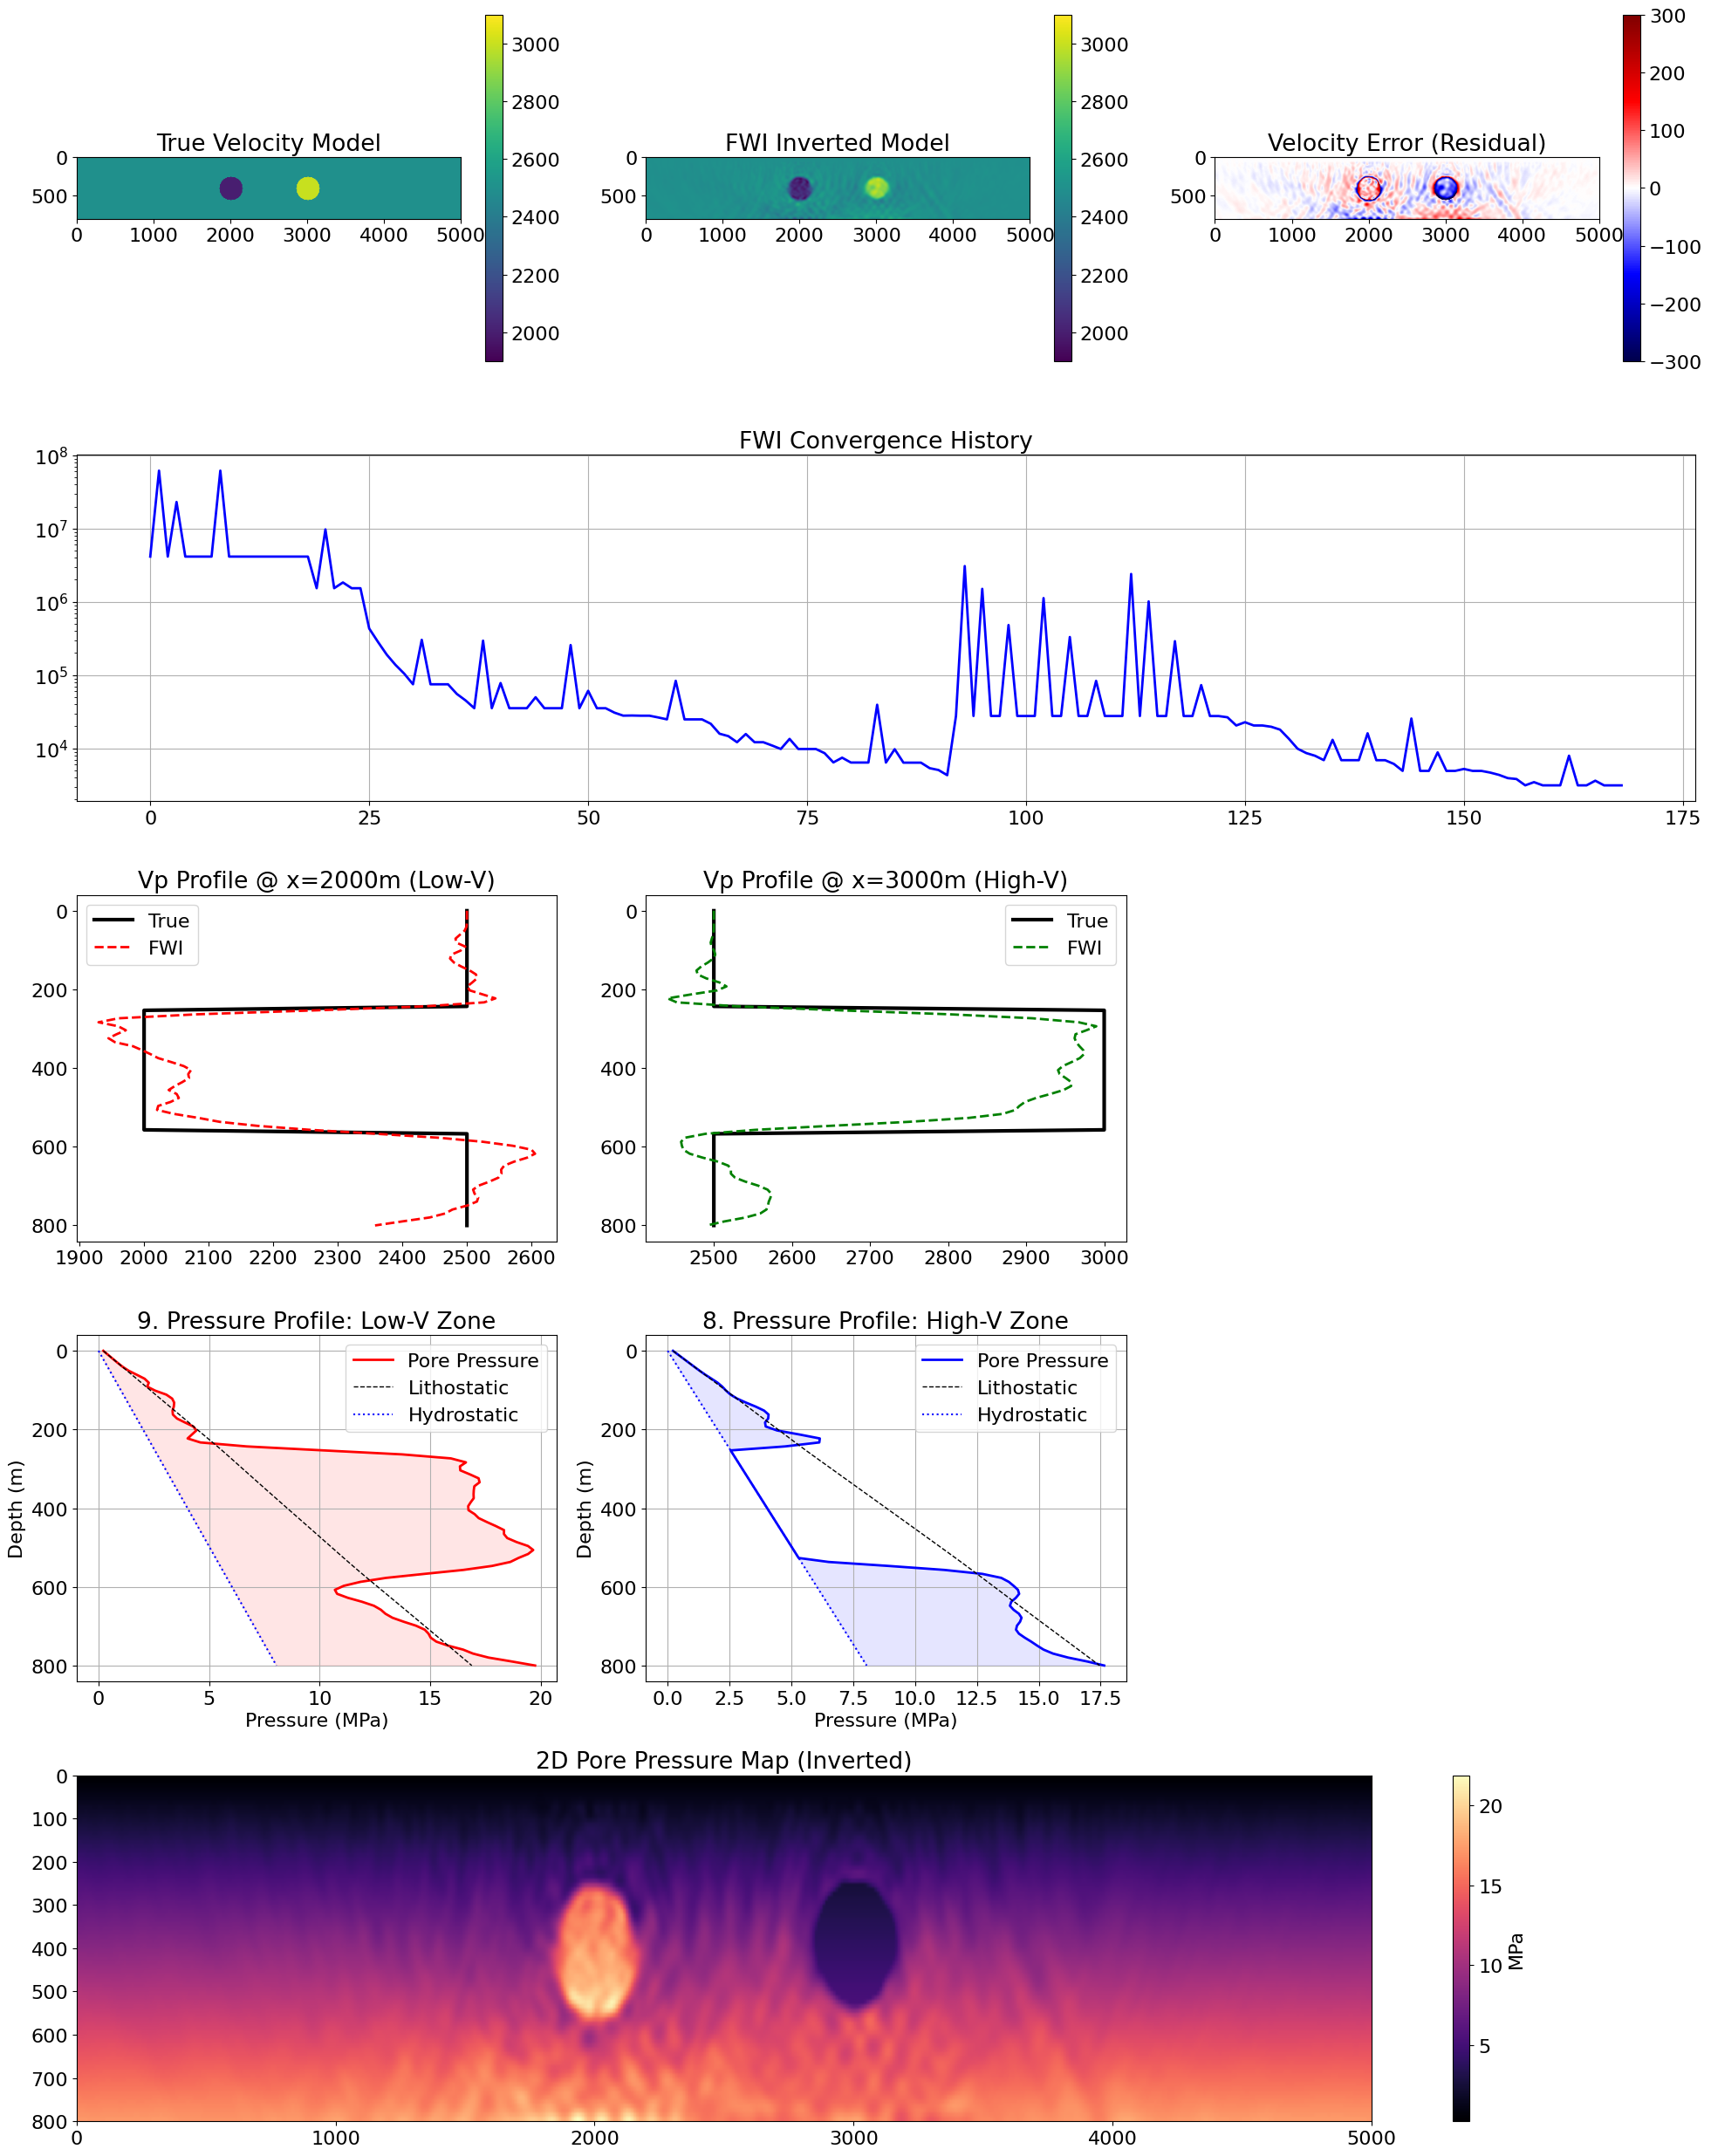

In [ ]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from scipy.optimize import minimize
from devito import configuration, Function, Eq, Operator, norm
from examples.seismic import Model, AcquisitionGeometry, Receiver
from examples.seismic.acoustic import AcousticWaveSolver

# Silence Devito logging
configuration['log-level'] = 'WARNING'

# ------------------ 1. Setup: Grid & Models --------------------
nx, nz = 500, 80
shape = (nx, nz)
spacing = (10., 10.)
origin = (0., 0.)
nbl = 20

v0 = 2.5        # Background velocity (km/s)
v_anomaly_low = 2.0   # Low velocity anomaly (km/s)
v_anomaly_high = 3.0  # High velocity anomaly (km/s)

velocity_true = np.full(shape, v0, dtype=np.float32)

# Circle 1: Low Velocity Anomaly (Center-Left)
cx1, cz1 = 2 * nx // 5, nz // 2
radius = 15
for i in range(nx):
    for j in range(nz):
        if (i - cx1)**2 + (j - cz1)**2 <= radius**2:
            velocity_true[i, j] = v_anomaly_low

# Circle 2: High Velocity Anomaly (Center-Right)
cx2, cz2 = 3 * nx // 5, nz // 2
for i in range(nx):
    for j in range(nz):
        if (i - cx2)**2 + (j - cz2)**2 <= radius**2:
            velocity_true[i, j] = v_anomaly_high

model_true = Model(vp=velocity_true, origin=origin, shape=shape, spacing=spacing,
                   nbl=nbl, space_order=4, bcs="damp")

velocity_init = np.full(shape, v0, dtype=np.float32)
model0 = Model(vp=velocity_init, origin=origin, shape=shape, spacing=spacing,
               nbl=nbl, space_order=4, bcs="damp")

# ------------------ 2. Acquisition Geometry -----------------------
nshots = 25
nreceivers = 250
t0, tn = 0.0, 1200.0

src_coords = np.empty((nshots, 2))
src_coords[:, 0] = np.linspace(0, model_true.domain_size[0], num=nshots)
src_coords[:, 1] = 20.

rec_coords = np.empty((nreceivers, 2))
rec_coords[:, 0] = np.linspace(0, model_true.domain_size[0], num=nreceivers)
rec_coords[:, 1] = 20.

# ------------------ 3. Optimization Logic -----------------------
fwi_iteration_history = []

def loss_and_grad(vp_flat, model, geometry, solver, nshots, src_coords, physical_shape, d_obs_list):
    v_clamped = vp_flat.reshape(physical_shape)
    model.vp.data[nbl:-nbl, nbl:-nbl] = v_clamped

    grad = Function(name="grad", grid=model.grid)
    residual = Receiver(name='residual', grid=model.grid, time_range=geometry.time_axis, coordinates=geometry.rec_positions)
    d_syn = Receiver(name='d_syn', grid=model.grid, time_range=geometry.time_axis, coordinates=geometry.rec_positions)

    objective = 0.
    for i in range(nshots):
        geometry.src_positions[0, :] = src_coords[i, :]
        _, u0, _ = solver.forward(vp=model.vp, save=True, rec=d_syn)

        residual.data[:] = d_syn.data[:] - d_obs_list[i].data[:]
        objective += .5 * np.linalg.norm(residual.data)**2
        solver.gradient(rec=residual, u=u0, vp=model.vp, grad=grad)

    grad_active = grad.data[nbl:-nbl, nbl:-nbl]
    v_active = model.vp.data[nbl:-nbl, nbl:-nbl]
    grad_dv = grad_active * (-2.0 / v_active**3)

    grad_dv[:, :7] = 0 # Mute surface
    grad_smoothed = gaussian_filter(grad_dv, sigma=1.2)

    max_val = np.max(np.abs(grad_smoothed))
    grad_final = grad_smoothed / (max_val + 1e-10)

    fwi_iteration_history.append(float(objective))
    print(f"   Objective: {objective:.4e}")
    return float(objective), grad_final.astype(np.float64).ravel()

# ------------------ 4. Execution -----------------------
frequencies = [0.003, 0.007, 0.015]
iterations = [60, 30, 20]

vp_curr_flat = model0.vp.data[nbl:-nbl, nbl:-nbl].flatten().astype(np.float64)

print("--- Starting Multiscale FWI ---")
for f_idx, f0 in enumerate(frequencies):
    print(f"\n>> Stage {f_idx+1}: frequency {f0*1000} Hz")
    geometry = AcquisitionGeometry(model_true, rec_coords, src_coords, t0=t0, tn=tn, f0=f0, src_type='Ricker')
    solver = AcousticWaveSolver(model_true, geometry, space_order=4)

    d_obs_list = []
    for i in range(nshots):
        geometry.src_positions[0, :] = src_coords[i, :]
        d_obs = Receiver(name='d_obs', grid=model_true.grid, time_range=geometry.time_axis, coordinates=geometry.rec_positions)
        solver.forward(vp=model_true.vp, rec=d_obs)
        d_obs_list.append(d_obs)

    res = minimize(loss_and_grad,
                   vp_curr_flat,
                   args=(model0, geometry, solver, nshots, src_coords, shape, d_obs_list),
                   method='L-BFGS-B',
                   jac=True,
                   bounds=[(1.8, 3.2)] * len(vp_curr_flat),
                   options={'maxiter': iterations[f_idx], 'ftol': 1e-5})

    vp_curr_flat = res.x

model0.vp.data[nbl:-nbl, nbl:-nbl] = vp_curr_flat.reshape(shape)

# ------------------ 5. Pressure Analysis -----------------
vp_fwi_final = model0.vp.data[nbl:-nbl, nbl:-nbl] * 1000.0
vp_true_final = model_true.vp.data[nbl:-nbl, nbl:-nbl] * 1000.0
nx_c, nz_c = vp_fwi_final.shape
depth_vector = np.linspace(0, nz_c * spacing[1], nz_c)

rho = 310.0 * (vp_fwi_final ** 0.25)
Sv_Pa = np.zeros_like(vp_fwi_final)
for i in range(nx_c):
    Sv_Pa[i, :] = np.cumsum(rho[i, :] * 9.81 * spacing[1])

# Hydrostatic Pressure Calculation
Ph_Pa = 1025.0 * 9.81 * depth_vector
Ph_MPa = Ph_Pa * 1e-6

# Bowers Method
V0, A_bow, B_bow = 5000.0, 10.0, 0.75
v_fts = vp_fwi_final * 3.28084
v_term = np.maximum(v_fts - V0, 1.0)
sigma_eff_Pa = ((v_term / A_bow)**(1.0/B_bow)) * 6894.76
v_ref_fts = (v0 * 1000 * 3.28084)
sigma_ref_Pa = (((v_ref_fts - V0) / A_bow)**(1.0/B_bow)) * 6894.76

Pp_Pa = np.maximum(Sv_Pa - (sigma_eff_Pa - sigma_ref_Pa), Ph_Pa)
Pp_MPa = Pp_Pa * 1e-6
Sv_MPa = Sv_Pa * 1e-6

# ------------------ 6. Integrated Visualization ---------------------
fig = plt.figure(figsize=(20, 25))
gs = fig.add_gridspec(5, 3)
extent = [0, nx*spacing[0], nz*spacing[1], 0]

# Row 1-3 remain the same...
ax1 = fig.add_subplot(gs[0, 0]); im1 = ax1.imshow(vp_true_final.T, extent=extent, cmap='viridis', vmin=1900, vmax=3100)
ax1.set_title("True Velocity Model"); plt.colorbar(im1, ax=ax1)
ax2 = fig.add_subplot(gs[0, 1]); im2 = ax2.imshow(vp_fwi_final.T, extent=extent, cmap='viridis', vmin=1900, vmax=3100)
ax2.set_title("FWI Inverted Model"); plt.colorbar(im2, ax=ax2)
ax3 = fig.add_subplot(gs[0, 2]); error = vp_fwi_final - vp_true_final
im3 = ax3.imshow(error.T, extent=extent, cmap='seismic', vmin=-300, vmax=300)
ax3.set_title("Velocity Error (Residual)"); plt.colorbar(im3, ax=ax3)

ax4 = fig.add_subplot(gs[1, :])
ax4.plot(fwi_iteration_history, color='blue', lw=2)
ax4.set_yscale('log'); ax4.set_title("FWI Convergence History"); ax4.grid(True)

ax5_v = fig.add_subplot(gs[2, 0])
ax5_v.plot(vp_true_final[cx1, :], depth_vector, 'k', lw=3, label='True')
ax5_v.plot(vp_fwi_final[cx1, :], depth_vector, 'r--', lw=2, label='FWI')
ax5_v.invert_yaxis(); ax5_v.set_title(f"Vp Profile @ x={cx1*10}m (Low-V)"); ax5_v.legend()

ax6_v = fig.add_subplot(gs[2, 1])
ax6_v.plot(vp_true_final[cx2, :], depth_vector, 'k', lw=3, label='True')
ax6_v.plot(vp_fwi_final[cx2, :], depth_vector, 'g--', lw=2, label='FWI')
ax6_v.invert_yaxis(); ax6_v.set_title(f"Vp Profile @ x={cx2*10}m (High-V)"); ax6_v.legend()

# Row 4: UPDATED PRESSURE PROFILES
# Low-V Pressure Profile
ax5_p = fig.add_subplot(gs[3, 0])
ax5_p.plot(Pp_MPa[cx1, :], depth_vector, 'r', lw=2, label='Pore Pressure')
ax5_p.plot(Sv_MPa[cx1, :], depth_vector, 'k--', lw=1, label='Lithostatic')
ax5_p.plot(Ph_MPa, depth_vector, 'b:', lw=1.5, label='Hydrostatic')
ax5_p.fill_betweenx(depth_vector, Ph_MPa, Pp_MPa[cx1, :], color='red', alpha=0.1) # Shading
ax5_p.invert_yaxis(); ax5_p.set_title(f"9. Pressure Profile: Low-V Zone"); ax5_p.legend(); ax5_p.grid(True)
ax5_p.set_xlabel("Pressure (MPa)"); ax5_p.set_ylabel("Depth (m)")

# High-V Pressure Profile
ax6_p = fig.add_subplot(gs[3, 1])
ax6_p.plot(Pp_MPa[cx2, :], depth_vector, 'b', lw=2, label='Pore Pressure')
ax6_p.plot(Sv_MPa[cx2, :], depth_vector, 'k--', lw=1, label='Lithostatic')
ax6_p.plot(Ph_MPa, depth_vector, 'b:', lw=1.5, label='Hydrostatic')
ax6_p.fill_betweenx(depth_vector, Ph_MPa, Pp_MPa[cx2, :], color='blue', alpha=0.1) # Shading
ax6_p.invert_yaxis(); ax6_p.set_title(f"8. Pressure Profile: High-V Zone"); ax6_p.legend(); ax6_p.grid(True)
ax6_p.set_xlabel("Pressure (MPa)"); ax6_p.set_ylabel("Depth (m)")

# Row 5: Final Pressure Map
ax7 = fig.add_subplot(gs[4, :])
im7 = ax7.imshow(Pp_MPa.T, extent=extent, cmap='magma', aspect='auto')
ax7.set_title("2D Pore Pressure Map (Inverted)")
plt.colorbar(im7, ax=ax7, label="MPa")

plt.tight_layout()
plt.show()

## Dual anomaly with layer (l-BFGS-B)

--- Starting Multiscale FWI ---

>> Stage 1: 5.0 Hz
   Objective: 3.8589e+06
   Objective: 7.2593e+07
   Objective: 5.5651e+06
   Objective: 2.7405e+06
   Objective: 1.5962e+06
   Objective: 1.1979e+06
   Objective: 7.5819e+05
   Objective: 5.8624e+05
   Objective: 5.2197e+05
   Objective: 5.0293e+05
   Objective: 4.6540e+05
   Objective: 4.4618e+05
   Objective: 4.3643e+05
   Objective: 4.1524e+05
   Objective: 4.0629e+05
   Objective: 3.9568e+05
   Objective: 3.8904e+05
   Objective: 3.8797e+05
   Objective: 3.8620e+05
   Objective: 3.8050e+05
   Objective: 3.7936e+05
   Objective: 3.7727e+05
   Objective: 3.7546e+05
   Objective: 3.7488e+05
   Objective: 3.7296e+05
   Objective: 3.7180e+05
   Objective: 3.7129e+05
   Objective: 3.7047e+05
   Objective: 3.6974e+05
   Objective: 3.6871e+05
   Objective: 3.6768e+05
   Objective: 3.6716e+05
   Objective: 3.6693e+05

>> Stage 2: 10.0 Hz
   Objective: 2.6406e+05
   Objective: 2.8495e+07
   Objective: 5.7159e+06
   Objective: 4.7301e+05
  

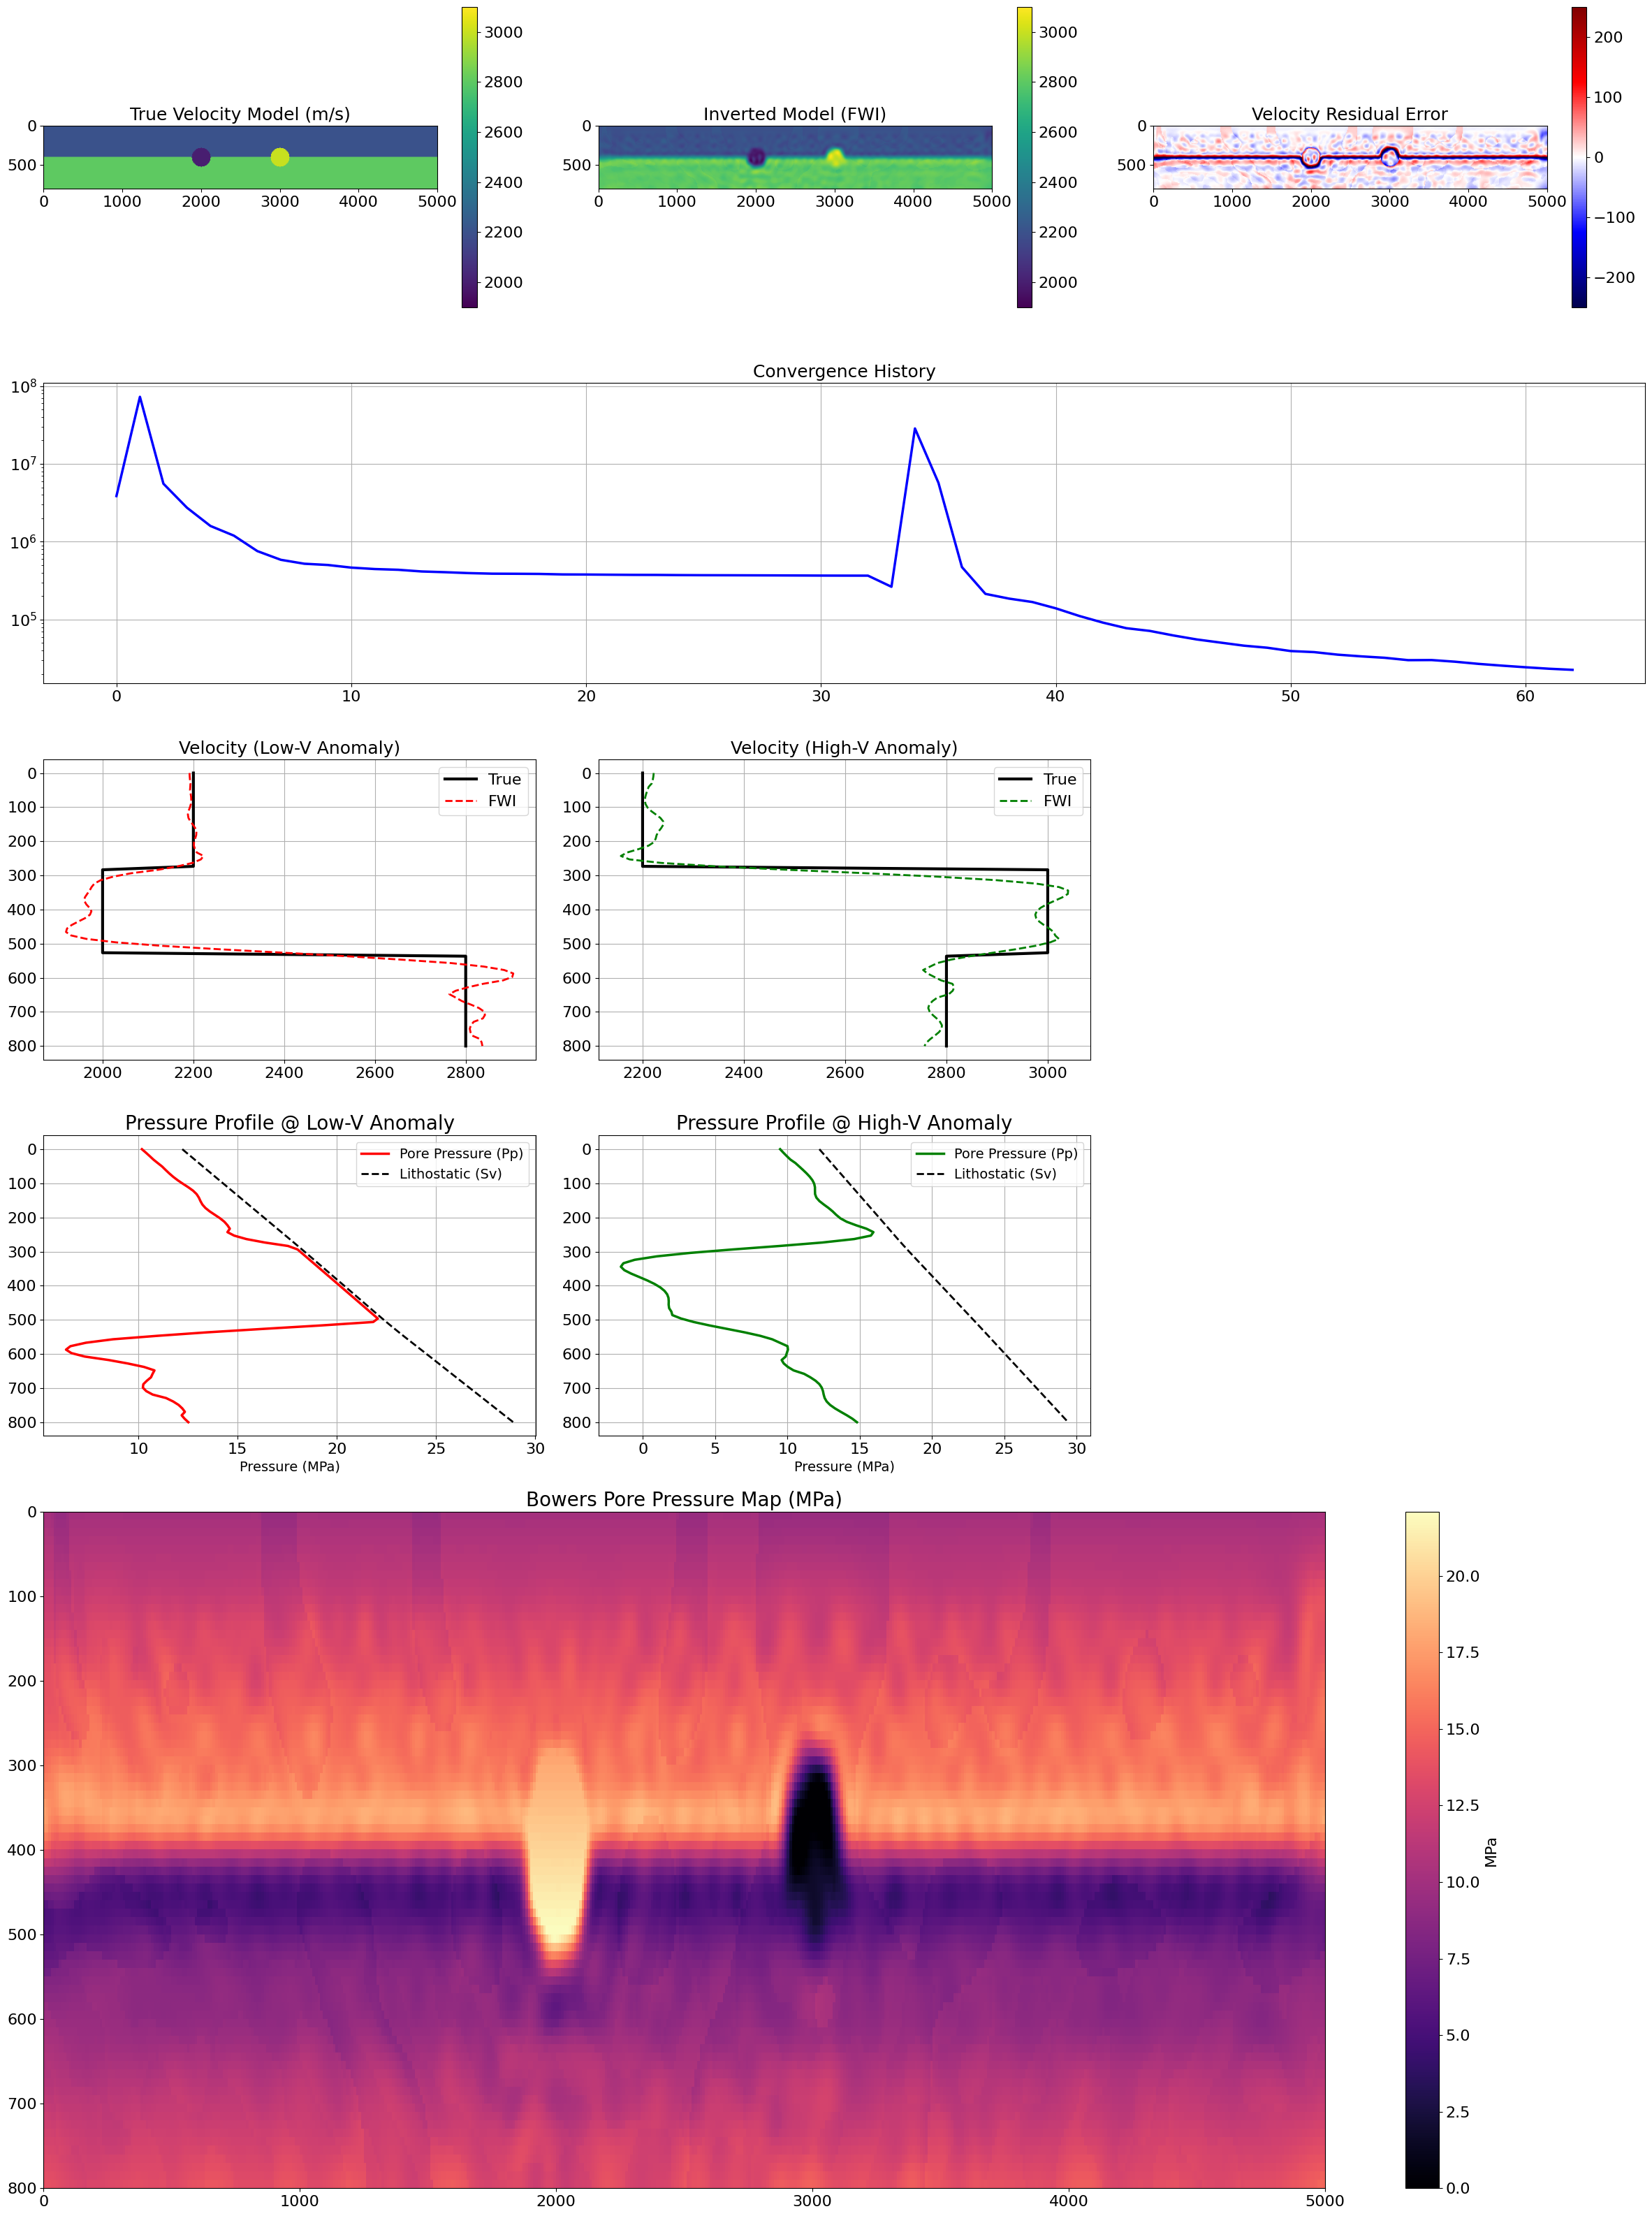

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from scipy.optimize import minimize

# Devito imports
from devito import configuration, Function
from examples.seismic import Model, AcquisitionGeometry, Receiver
from examples.seismic.acoustic import AcousticWaveSolver

# Silence Devito logging
configuration['log-level'] = 'WARNING'

# ------------------ 1. Setup: Grid & Models --------------------
nx, nz = 500, 80
shape = (nx, nz)
spacing = (10., 10.)
origin = (0., 0.)
nbl = 20

v_top, v_bottom = 2.2, 2.8
v_anomaly_low, v_anomaly_high = 2.0, 3.0

# Create True Model
velocity_true = np.full(shape, v_top, dtype=np.float32)
velocity_true[:, nz // 2:] = v_bottom

cx1, cz1 = 2 * nx // 5, nz // 2
cx2, cz2 = 3 * nx // 5, nz // 2
radius = 12
for i in range(nx):
    for j in range(nz):
        dist1 = np.sqrt((i - cx1)**2 + (j - cz1)**2)
        dist2 = np.sqrt((i - cx2)**2 + (j - cz2)**2)
        if dist1 <= radius: velocity_true[i, j] = v_anomaly_low
        if dist2 <= radius: velocity_true[i, j] = v_anomaly_high

model_true = Model(vp=velocity_true, origin=origin, shape=shape, spacing=spacing,
                   nbl=nbl, space_order=4, bcs="damp")

# Initial Model (Smooth background)
v_init = np.full(shape, v_top, dtype=np.float32)
v_init[:, nz // 2:] = v_bottom
model0 = Model(vp=gaussian_filter(v_init, sigma=5), origin=origin, shape=shape, spacing=spacing,
               nbl=nbl, space_order=4, bcs="damp")

# ------------------ 2. Acquisition Geometry -----------------------
nshots = 25
nreceivers = 251
t0, tn = 0.0, 1400.0

src_coords = np.empty((nshots, 2))
src_coords[:, 0] = np.linspace(0, model_true.domain_size[0], num=nshots)
src_coords[:, 1] = 20.

rec_coords = np.empty((nreceivers, 2))
rec_coords[:, 0] = np.linspace(0, model_true.domain_size[0], num=nreceivers)
rec_coords[:, 1] = 20.

# ------------------ 3. Optimization Logic -----------------------
fwi_iteration_history = []

def loss_and_grad(vp_flat, model, geometry, solver, nshots, src_coords, physical_shape, d_obs_list, current_sigma):
    v_clamped = vp_flat.reshape(physical_shape)
    model.vp.data[nbl:-nbl, nbl:-nbl] = v_clamped

    grad = Function(name="grad", grid=model.grid)
    residual = Receiver(name='residual', grid=model.grid, time_range=geometry.time_axis, coordinates=geometry.rec_positions)
    d_syn = Receiver(name='d_syn', grid=model.grid, time_range=geometry.time_axis, coordinates=geometry.rec_positions)

    objective = 0.
    for i in range(nshots):
        geometry.src_positions[0, :] = src_coords[i, :]
        _, u0, _ = solver.forward(vp=model.vp, save=True, rec=d_syn)
        residual.data[:] = d_syn.data[:] - d_obs_list[i].data[:]
        objective += .5 * np.linalg.norm(residual.data)**2
        solver.gradient(rec=residual, u=u0, vp=model.vp, grad=grad)

    grad_active = grad.data[nbl:-nbl, nbl:-nbl]
    v_active = model.vp.data[nbl:-nbl, nbl:-nbl]
    grad_dv = grad_active * (-2.0 / v_active**3)

    depth_gain = np.linspace(1.0, 6.0, nz)
    grad_dv = grad_dv * depth_gain
    grad_dv[:, :12] = 0
    grad_smoothed = gaussian_filter(grad_dv, sigma=current_sigma)

    fwi_iteration_history.append(float(objective))
    print(f"   Objective: {objective:.4e}")

    return float(objective), grad_smoothed.astype(np.float64).ravel()

# ------------------ 4. Execution -----------------------
frequencies = [0.005, 0.010]
iterations = [30, 25]
sigmas = [5.0, 2.0]

vp_curr_flat = model0.vp.data[nbl:-nbl, nbl:-nbl].flatten().astype(np.float64)

print("--- Starting Multiscale FWI ---")
for f_idx, f0 in enumerate(frequencies):
    print(f"\n>> Stage {f_idx+1}: {f0*1000} Hz")
    geometry = AcquisitionGeometry(model_true, rec_coords, src_coords, t0=t0, tn=tn, f0=f0, src_type='Ricker')
    solver = AcousticWaveSolver(model_true, geometry, space_order=4)

    d_obs_list = []
    for i in range(nshots):
        geometry.src_positions[0, :] = src_coords[i, :]
        d_obs = Receiver(name='d_obs', grid=model_true.grid, time_range=geometry.time_axis, coordinates=geometry.rec_positions)
        solver.forward(vp=model_true.vp, rec=d_obs)
        d_obs_list.append(d_obs)

    res = minimize(loss_and_grad, vp_curr_flat,
                   args=(model0, geometry, solver, nshots, src_coords, shape, d_obs_list, sigmas[f_idx]),
                   method='L-BFGS-B', jac=True, bounds=[(1.8, 3.2)] * len(vp_curr_flat),
                   options={'maxiter': iterations[f_idx], 'ftol': 1e-4})
    vp_curr_flat = res.x

model0.vp.data[nbl:-nbl, nbl:-nbl] = vp_curr_flat.reshape(shape)

# ------------------ 5. Bowers Pressure Analysis (Calibrated) -----------------
vp_fwi = model0.vp.data[nbl:-nbl, nbl:-nbl] * 1000.0
vp_true = model_true.vp.data[nbl:-nbl, nbl:-nbl] * 1000.0
depth_vector = np.linspace(0, nz * spacing[1], nz)

# 1. Lithostatic Stress (Sv) with 12 MPa Base (Water column) to ensure positivity
rho = 310.0 * (vp_fwi ** 0.25)
Sv_MPa = np.zeros_like(vp_fwi)
for i in range(nx):
    Sv_MPa[i, :] = (np.cumsum(rho[i, :] * 9.81 * spacing[1]) * 1e-6) + 12.0

# 2. Bowers Pore Pressure
# V0=2100, A=0.31, B=1.00 ensures Bottom Pressure ~ 5.5 MPa
# and keeps the high-velocity "pit" anomaly positive.
V0, A_bow, B_bow = 2100.0, 0.31, 1.00

def calc_pp(v_data, sv_data):
    v_term = np.maximum(v_data - V0, 10.0)
    sigma_e = (v_term / A_bow)**(1.0 / B_bow) * 0.00689476
    return sv_data - sigma_e

Pp_MPa = calc_pp(vp_fwi, Sv_MPa)

# ------------------ 6. Integrated Visualization ---------------------
fig = plt.figure(figsize=(24, 32))
gs = fig.add_gridspec(6, 3)
extent = [0, nx*spacing[0], nz*spacing[1], 0]

# Row 1: Velocity Models & Residual
ax1 = fig.add_subplot(gs[0, 0]); im1 = ax1.imshow(vp_true.T, extent=extent, cmap='viridis', vmin=1900, vmax=3100)
ax1.set_title("True Velocity Model (m/s)", fontsize=18); plt.colorbar(im1, ax=ax1)
ax2 = fig.add_subplot(gs[0, 1]); im2 = ax2.imshow(vp_fwi.T, extent=extent, cmap='viridis', vmin=1900, vmax=3100)
ax2.set_title("Inverted Model (FWI)", fontsize=18); plt.colorbar(im2, ax=ax2)
ax3 = fig.add_subplot(gs[0, 2]); err = vp_fwi - vp_true
im3 = ax3.imshow(err.T, extent=extent, cmap='seismic', vmin=-250, vmax=250)
ax3.set_title("Velocity Residual Error", fontsize=18); plt.colorbar(im3, ax=ax3)

# Row 2: Convergence History
ax4 = fig.add_subplot(gs[1, :])
ax4.plot(fwi_iteration_history, color='blue', lw=2.5)
ax4.set_yscale('log'); ax4.set_title("Convergence History", fontsize=18); ax4.grid(True)

# Row 3: Velocity Profiles
ax5 = fig.add_subplot(gs[2, 0])
ax5.plot(vp_true[cx1, :], depth_vector, 'k', lw=3, label='True')
ax5.plot(vp_fwi[cx1, :], depth_vector, 'r--', lw=2, label='FWI')
ax5.invert_yaxis(); ax5.set_title("Velocity (Low-V Anomaly)", fontsize=18); ax5.legend(); ax5.grid(True)

ax6 = fig.add_subplot(gs[2, 1])
ax6.plot(vp_true[cx2, :], depth_vector, 'k', lw=3, label='True')
ax6.plot(vp_fwi[cx2, :], depth_vector, 'g--', lw=2, label='FWI')
ax6.invert_yaxis(); ax6.set_title("Velocity (High-V Anomaly)", fontsize=18); ax6.legend(); ax6.grid(True)

# Row 4: Pressure Profiles
ax7 = fig.add_subplot(gs[3, 0])
ax7.plot(Pp_MPa[cx1, :], depth_vector, 'r-', lw=2.5, label='Pore Pressure (Pp)')
ax7.plot(Sv_MPa[cx1, :], depth_vector, 'k--', lw=2, label='Lithostatic (Sv)')
ax7.invert_yaxis(); ax7.set_title("Pressure Profile @ Low-V Anomaly", fontsize=20)
ax7.legend(fontsize=14); ax7.grid(True); ax7.set_xlabel("Pressure (MPa)", fontsize=14)

ax8 = fig.add_subplot(gs[3, 1])
ax8.plot(Pp_MPa[cx2, :], depth_vector, 'g-', lw=2.5, label='Pore Pressure (Pp)')
ax8.plot(Sv_MPa[cx2, :], depth_vector, 'k--', lw=2, label='Lithostatic (Sv)')
ax8.invert_yaxis(); ax8.set_title("Pressure Profile @ High-V Anomaly", fontsize=20)
ax8.legend(fontsize=14); ax8.grid(True); ax8.set_xlabel("Pressure (MPa)", fontsize=14)

# Row 5 & 6: Final Pressure Map (Positive Values, High Contrast)
ax9 = fig.add_subplot(gs[4:6, :])
# Set vmin=0 to explicitly ensure the map shows only positive values
im9 = ax9.imshow(Pp_MPa.T, extent=extent, cmap='magma', aspect='auto', vmin=0)
ax9.set_title("Bowers Pore Pressure Map (MPa)", fontsize=20)
plt.colorbar(im9, ax=ax9, label='MPa')

plt.tight_layout()
plt.show()